# Diamond Price Prediction Pipeline Assignment

## Assignment-11: Concept of Pipeline

### Objective

This assignment demonstrates the complete machine learning workflow using Scikit-learn Pipelines.

The notebook covers:

- Initial Exploratory Data Analysis (EDA)
- Manual preprocessing for visualization
- Proper train-test split workflow
- Feature engineering
- Log transformation
- Standardization
- Pipeline construction
- Model training
- Model evaluation

The assignment also demonstrates how to avoid data leakage by ensuring preprocessing parameters are learned only from the training data.

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    FunctionTransformer
)

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline as SkPipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import importlib
import Helper_functions as hf

importlib.reload(hf)

<module 'Helper_functions' from '/Users/amolsingh/Documents/code/IITB-DSAI/Programming for machine learning/Assignments/Helper_functions.py'>


Initial EDA - Untransformed Data

Dataset Shape: 53794 rows × 10 columns

Total Duplicate Rows: 0

Total Missing Values: 0

Missing Values Per Column:
No Missing Values

Generating Histograms...


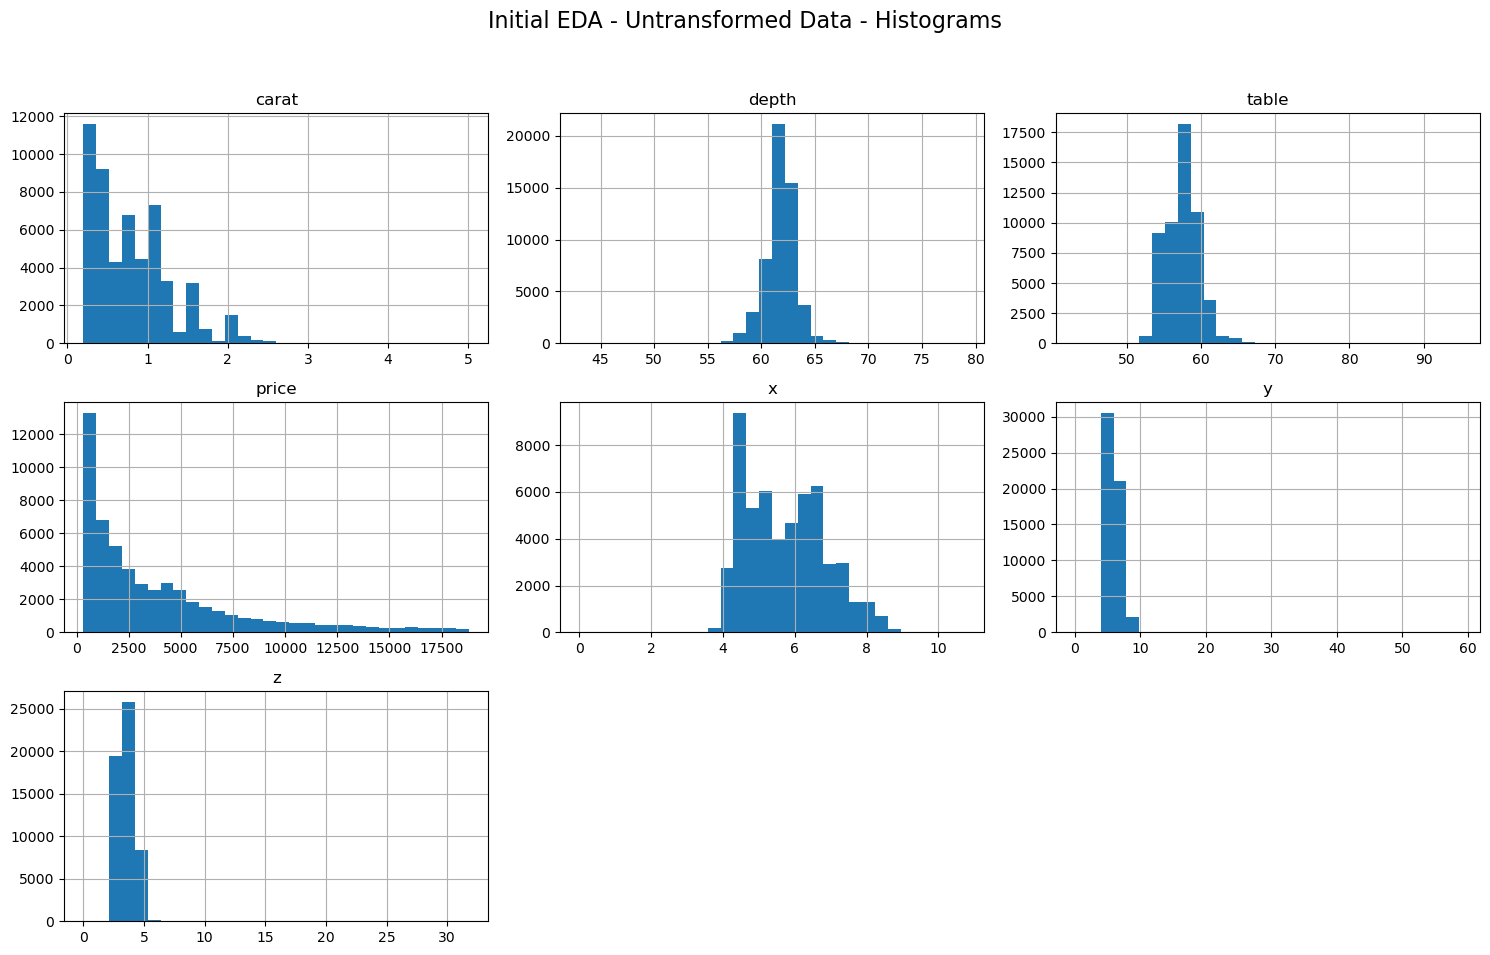


Generating Boxplots...


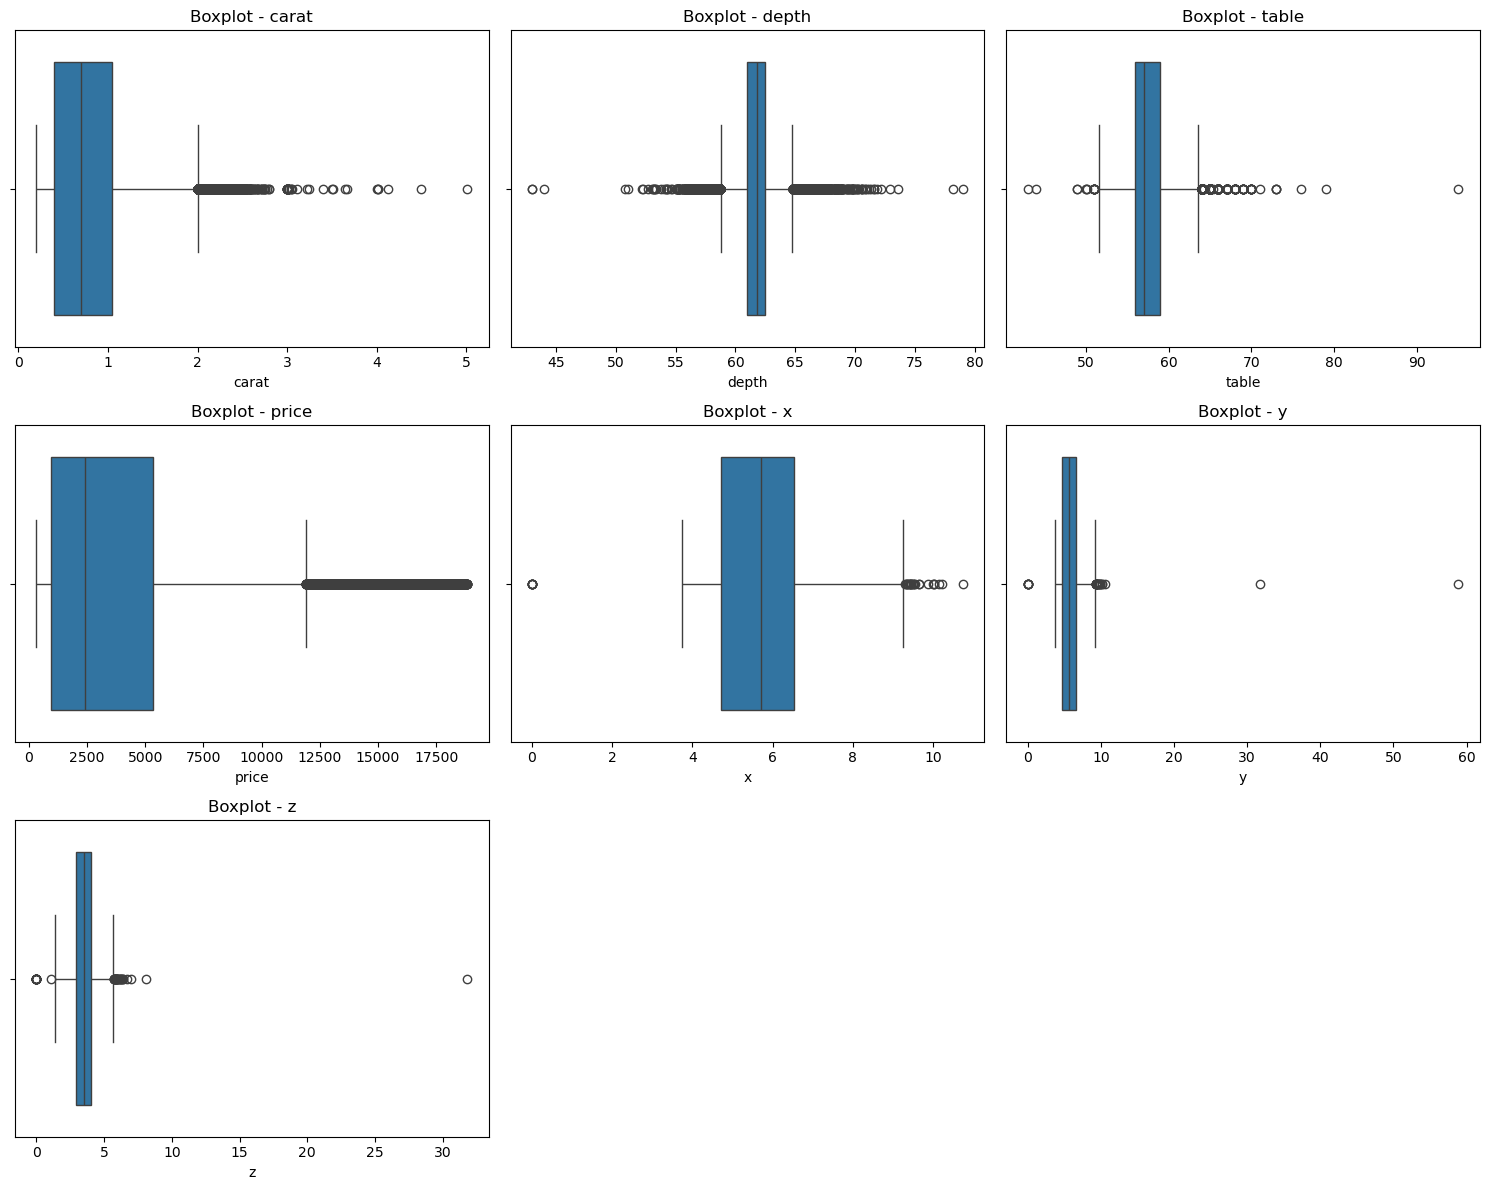


Generating Heatmap and Consolidated Boxplot...


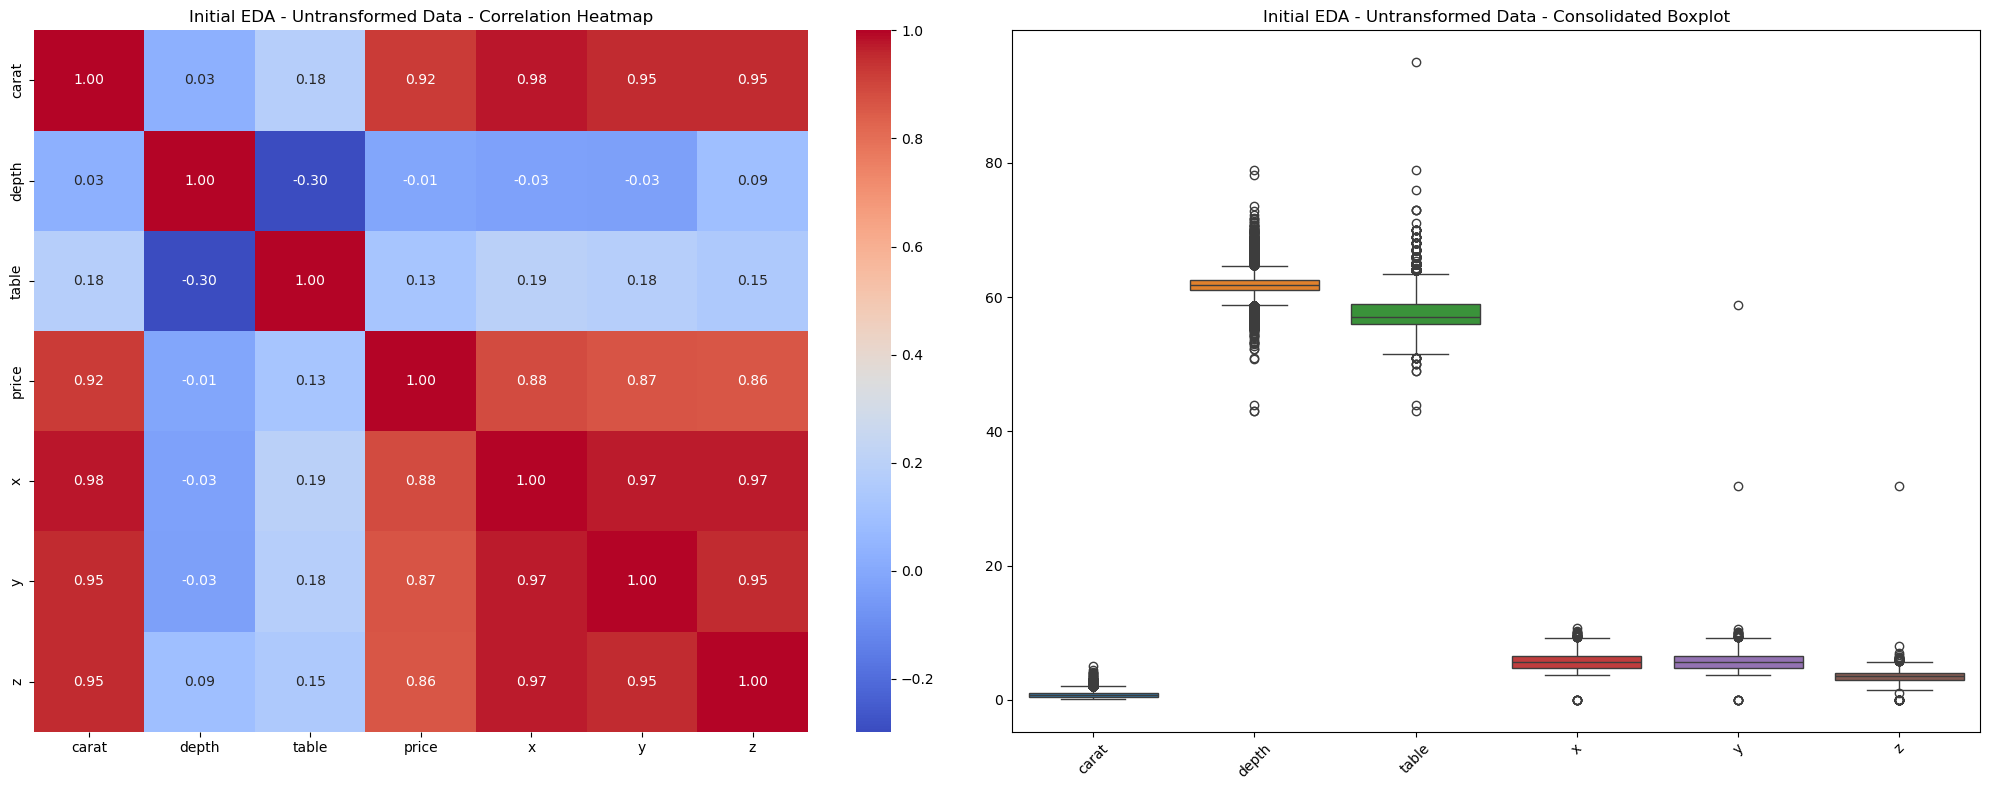


Generating Count Plots...


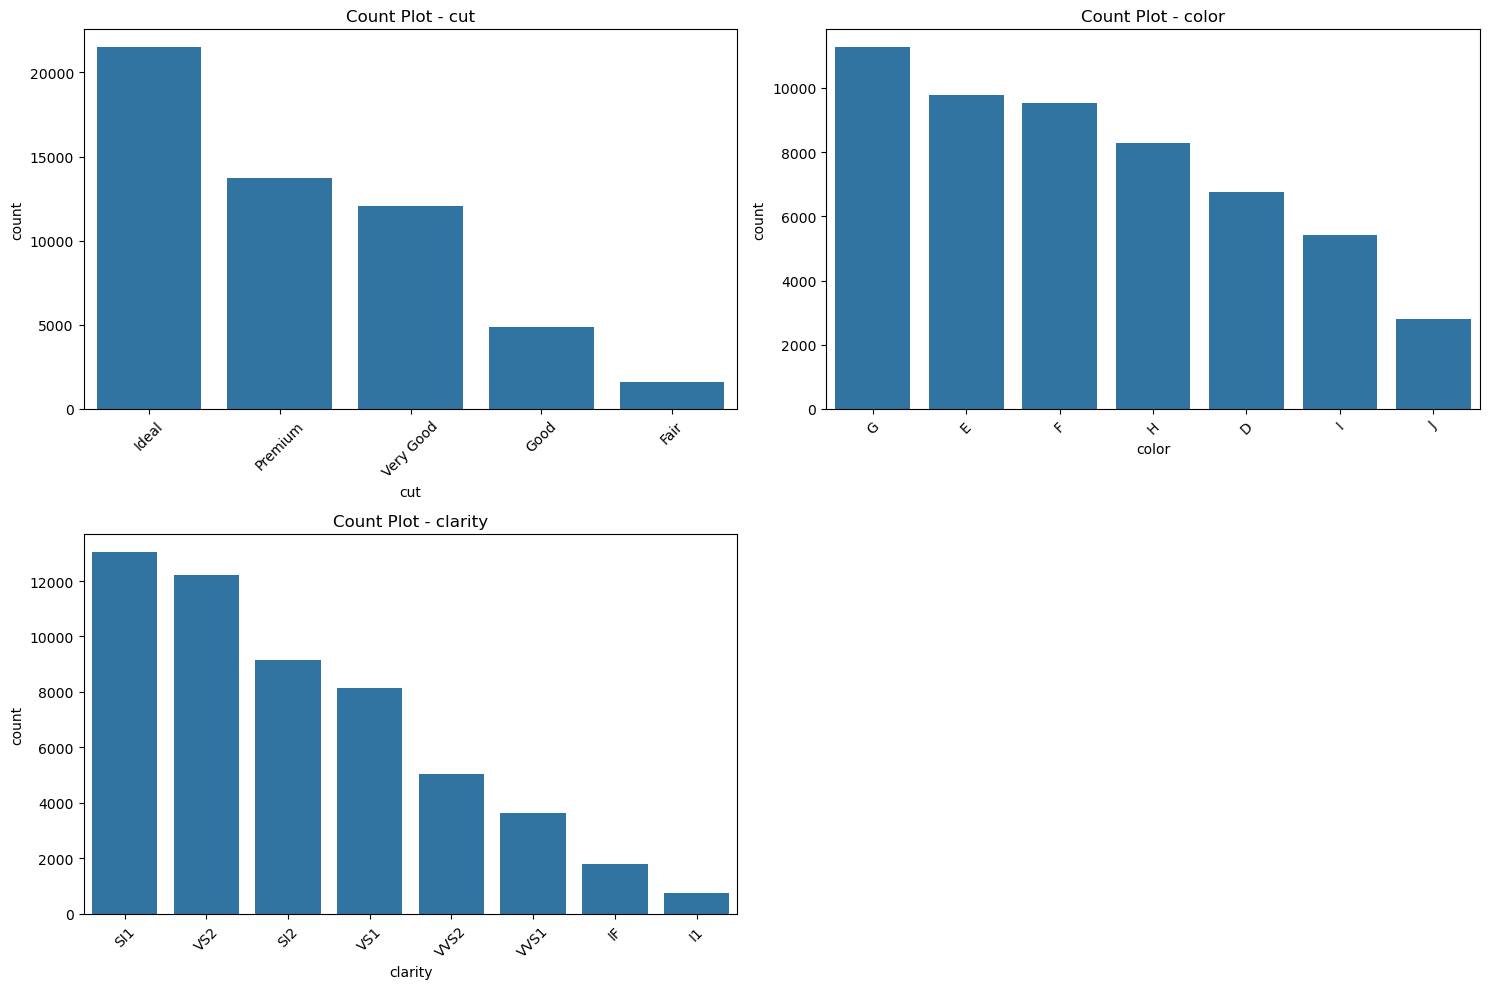


Diagnostics Completed Successfully!

Training Data Metrics
RMSE : 526.3220
MAE  : 296.4762
R²   : 0.9828


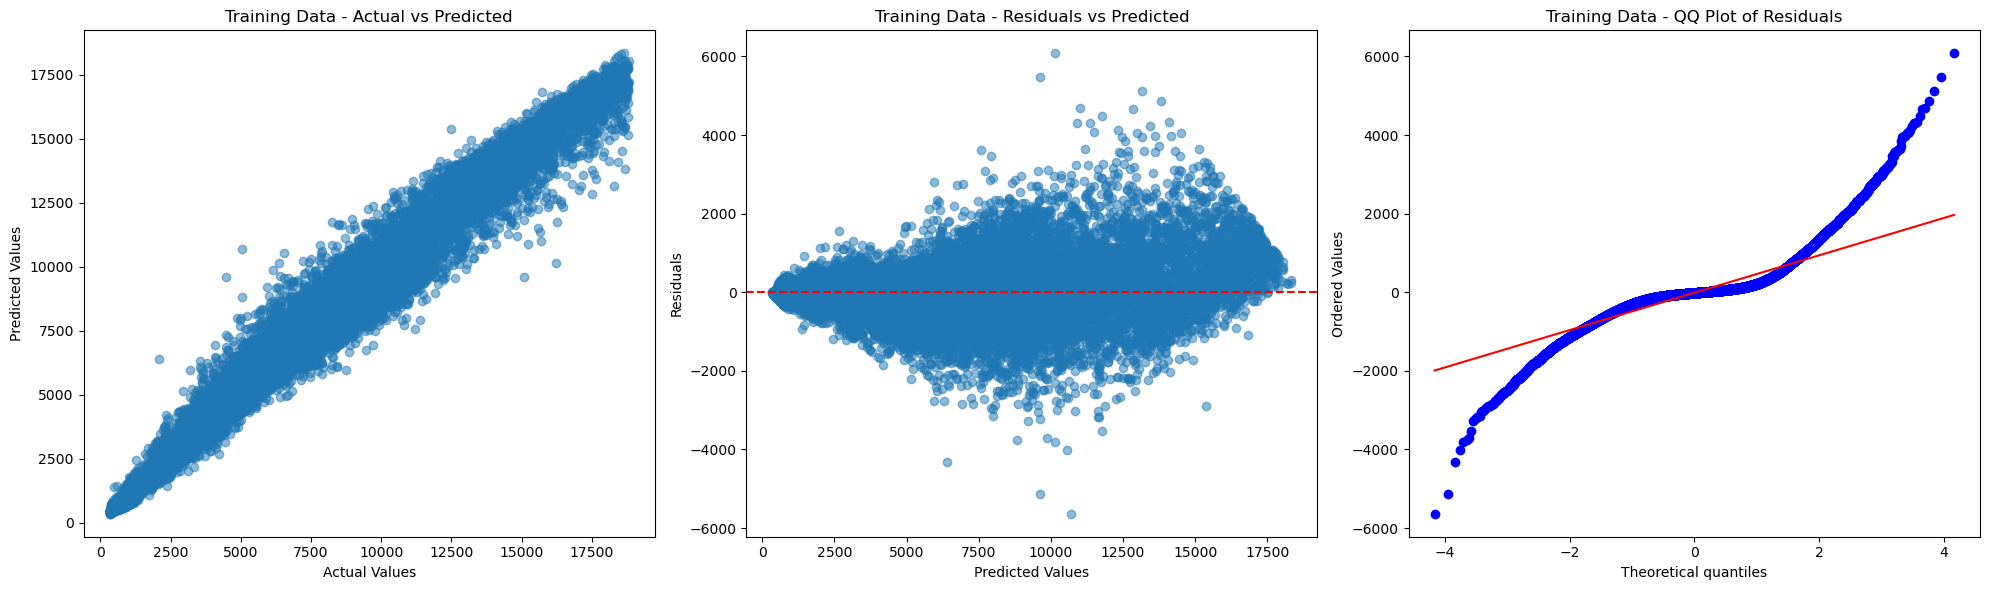


Test Data Metrics
RMSE : 1341.2260
MAE  : 766.3338
R²   : 0.8820


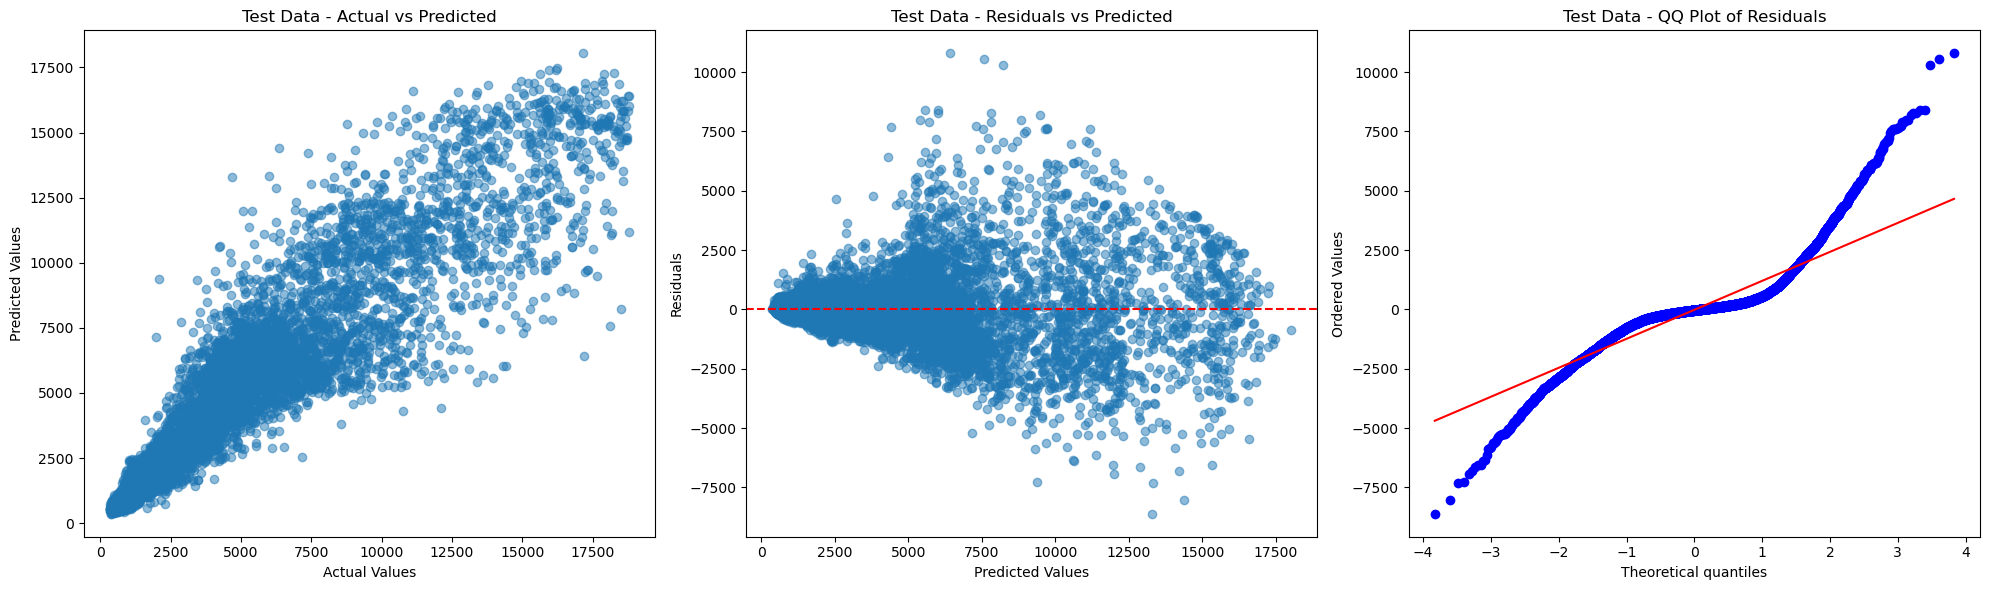

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...t 0x169cf1800>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword argu

In [27]:
def analyze_diamond_data(
    file_path='data/Diamond_Price_Prediction_cleaned.csv'
):

    df = pd.read_csv(file_path)

    df = df.rename(columns={
        'Carat(Weight of Daimond)': 'carat',
        'Cut(Quality)': 'cut',
        'Color': 'color',
        'Clarity': 'clarity',
        'Depth': 'depth',
        'Table': 'table',
        'Price(in US dollars)': 'price',
        'X(length)': 'x',
        'Y(width)': 'y',
        'Z(Depth)': 'z'
    })

    hf.print_diagnostics(df, "Initial EDA - Untransformed Data", target_col='price')

    return df

hf.run_pipeline_log(analyze_diamond_data('data/Diamond_Price_Prediction_cleaned.csv'), 'price')


Initial EDA - Untransformed Data

Dataset Shape: 53794 rows × 10 columns

Total Duplicate Rows: 0

Total Missing Values: 0

Missing Values Per Column:
No Missing Values

Generating Histograms...


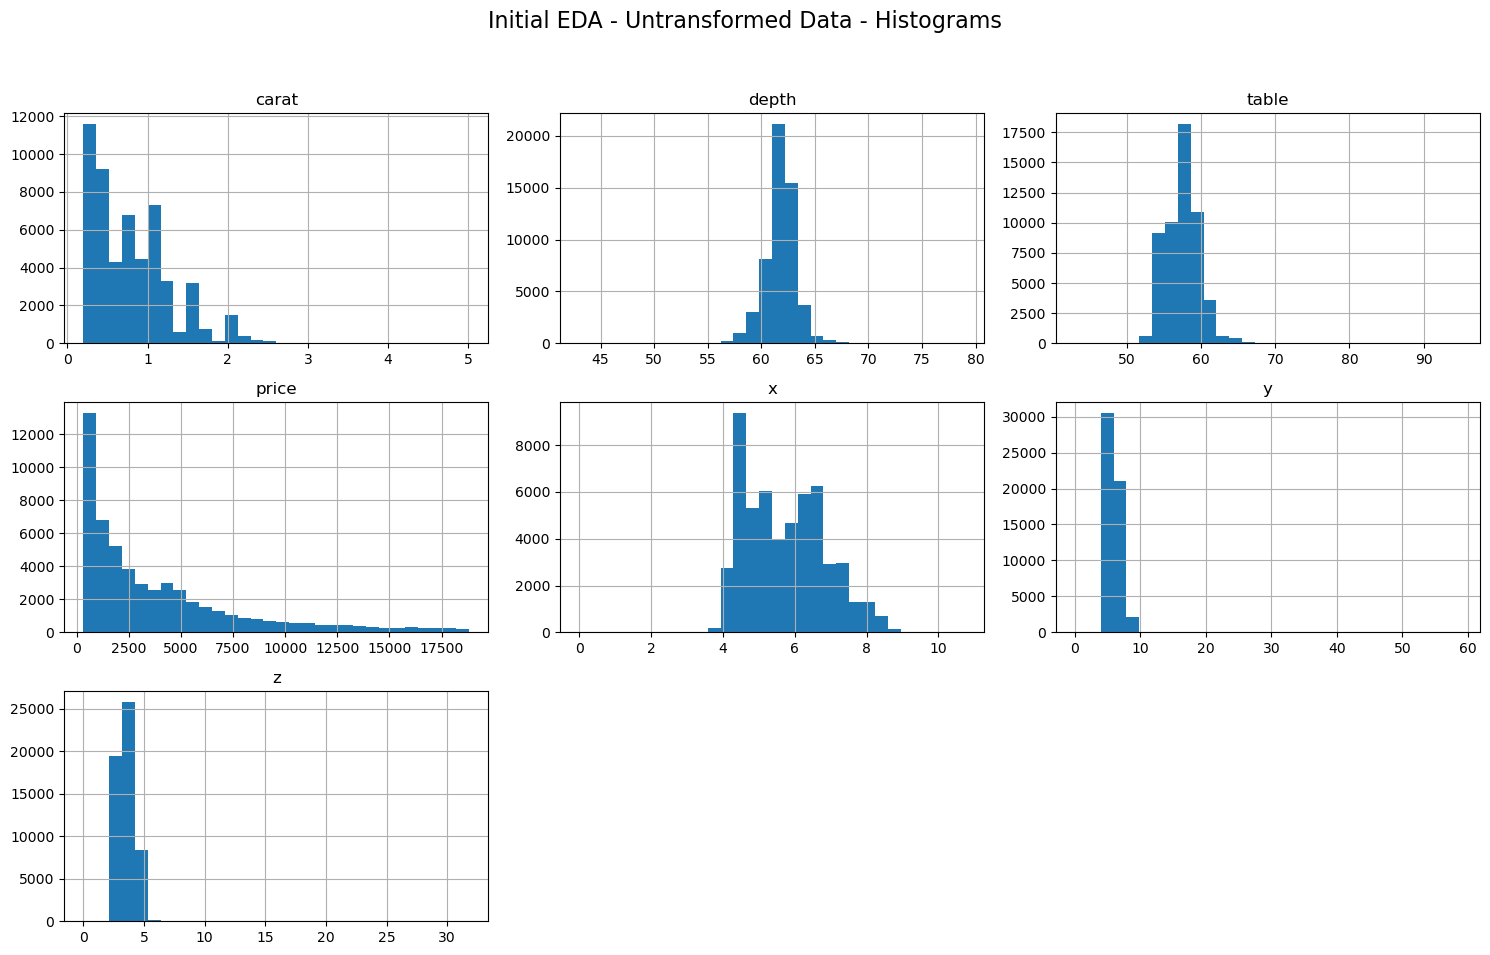


Generating Boxplots...


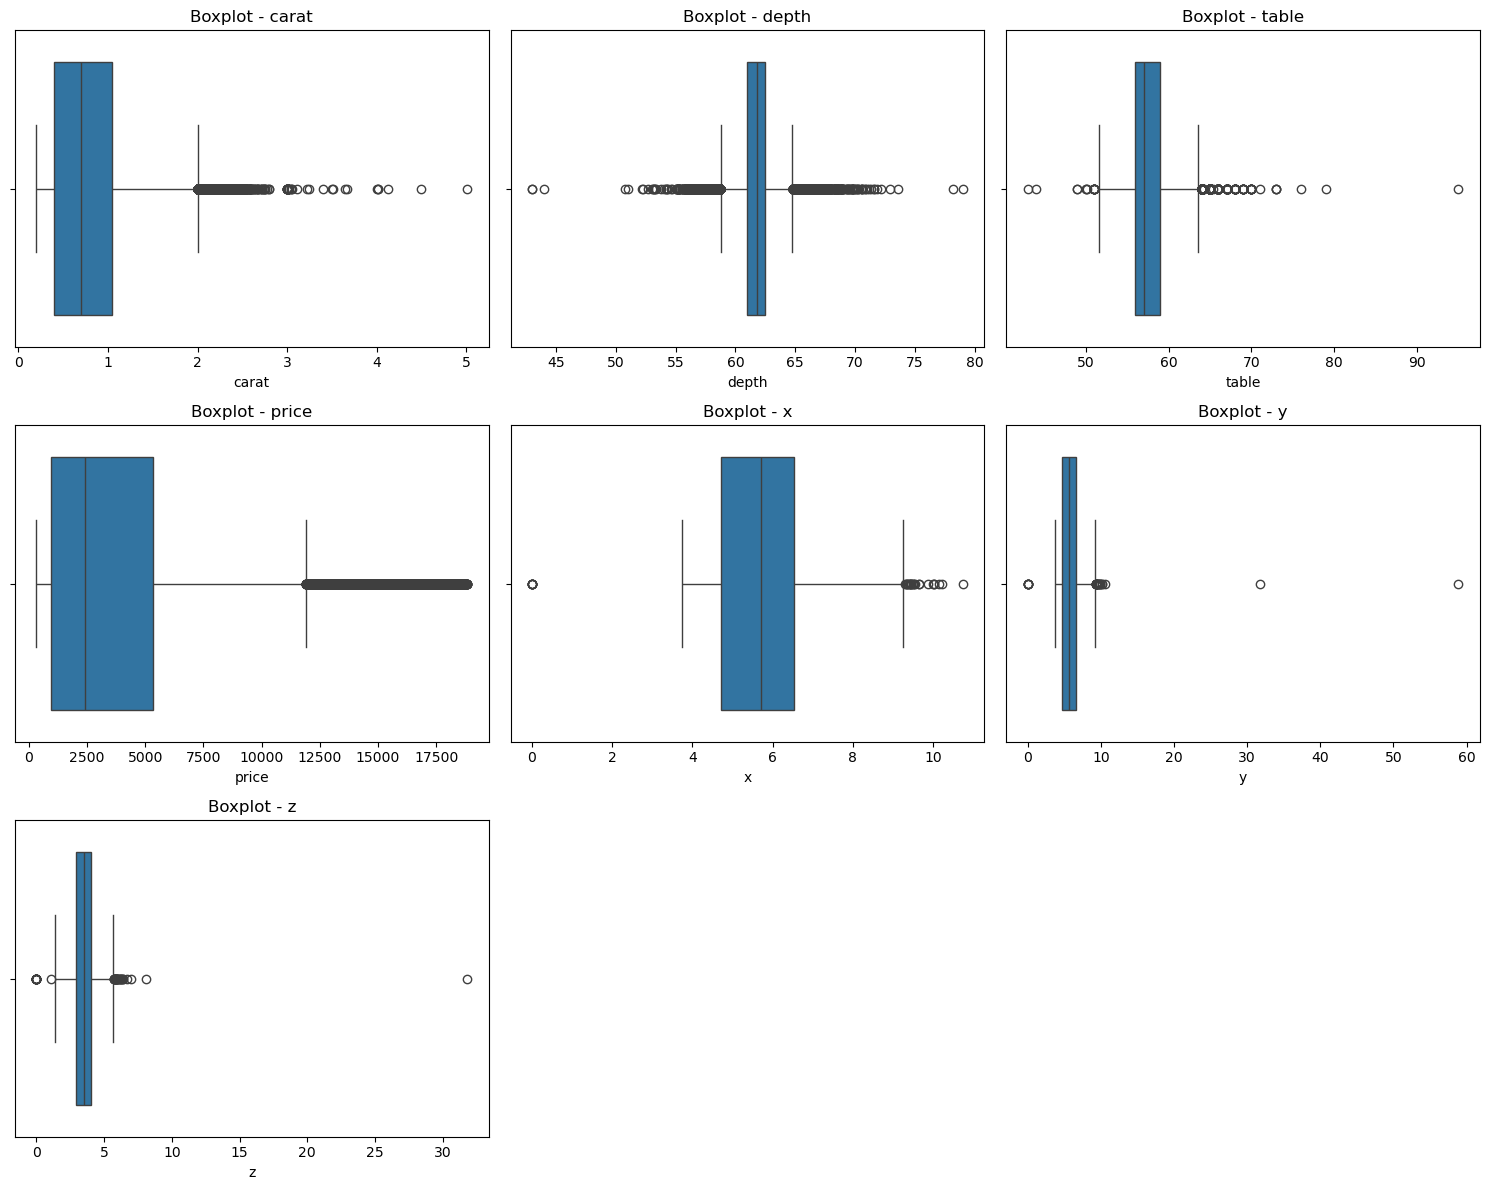


Generating Heatmap and Consolidated Boxplot...


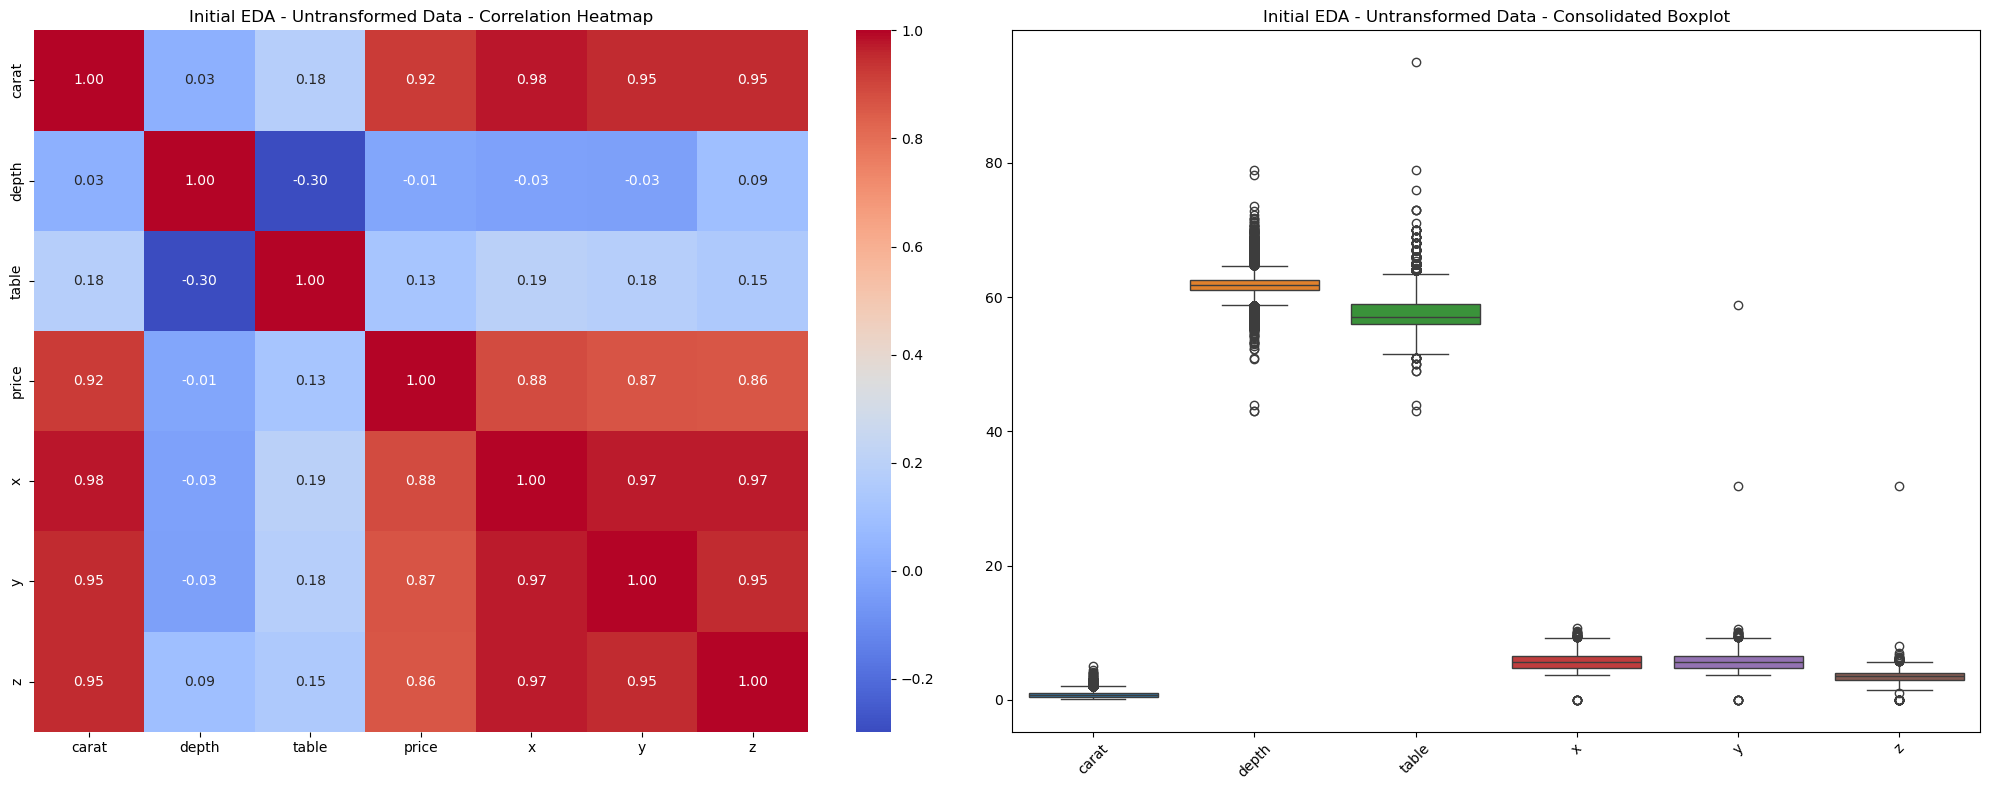


Generating Count Plots...


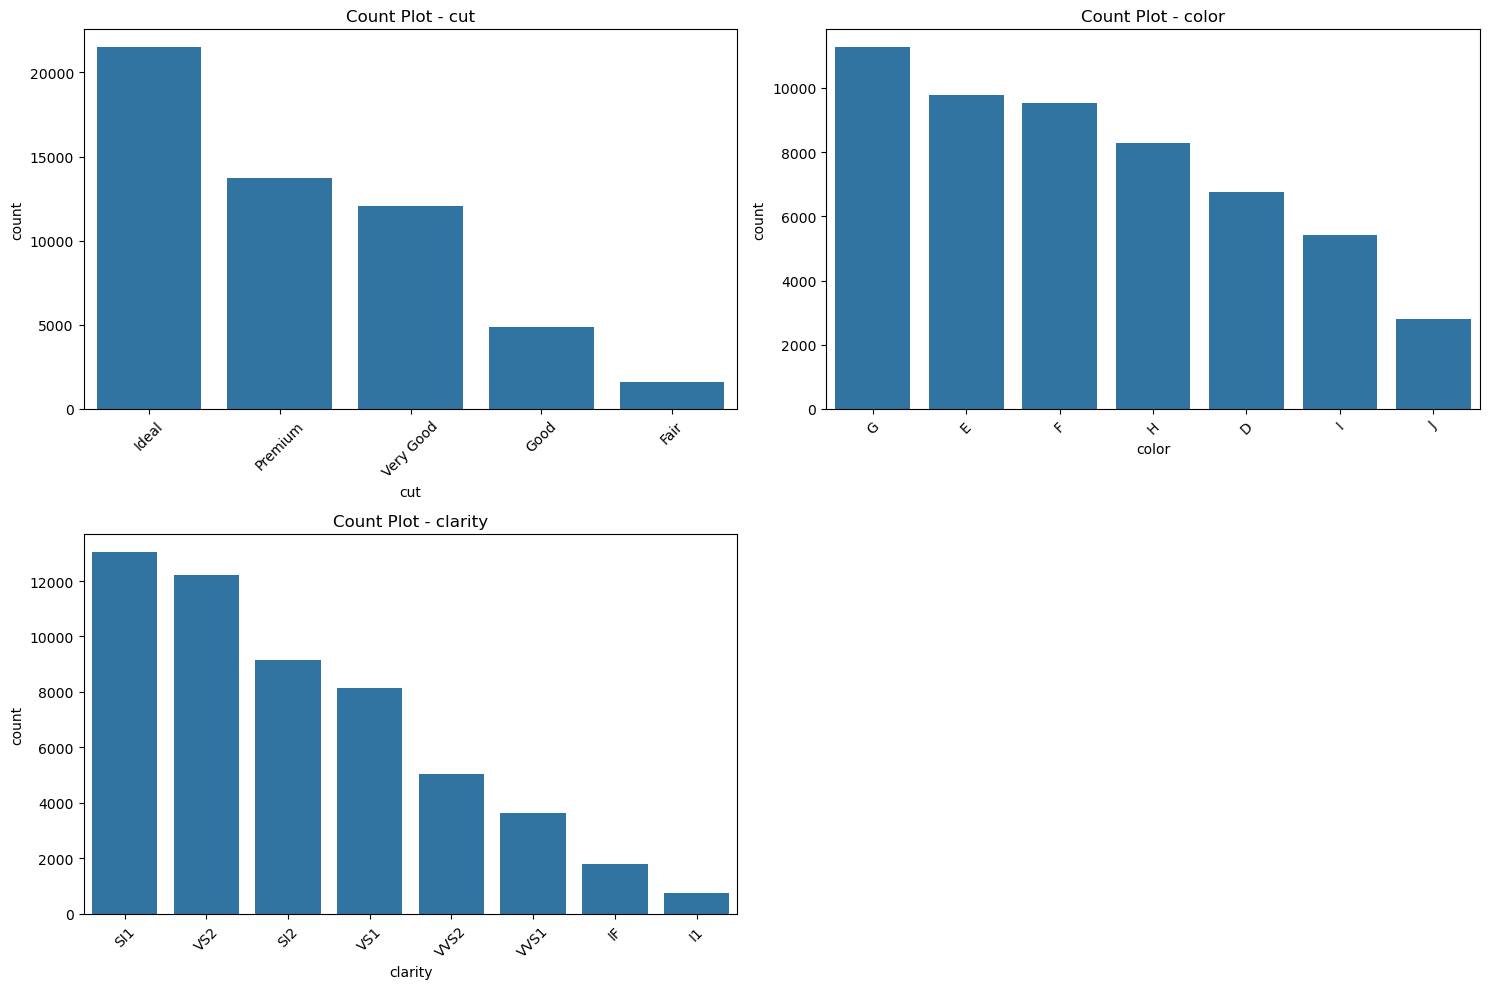


Diagnostics Completed Successfully!

Train-Test Split Completed

X_train Shape : (43035, 7)
X_test Shape  : (10759, 7)

y_train Shape : (43035,)
y_test Shape  : (10759,)

Train (Post Log, Pre Scaling)

Dataset Shape: 43035 rows × 8 columns

Total Duplicate Rows: 40

Total Missing Values: 41

Missing Values Per Column:
x: 6
y: 5
z: 15
volume: 15

Generating Histograms...


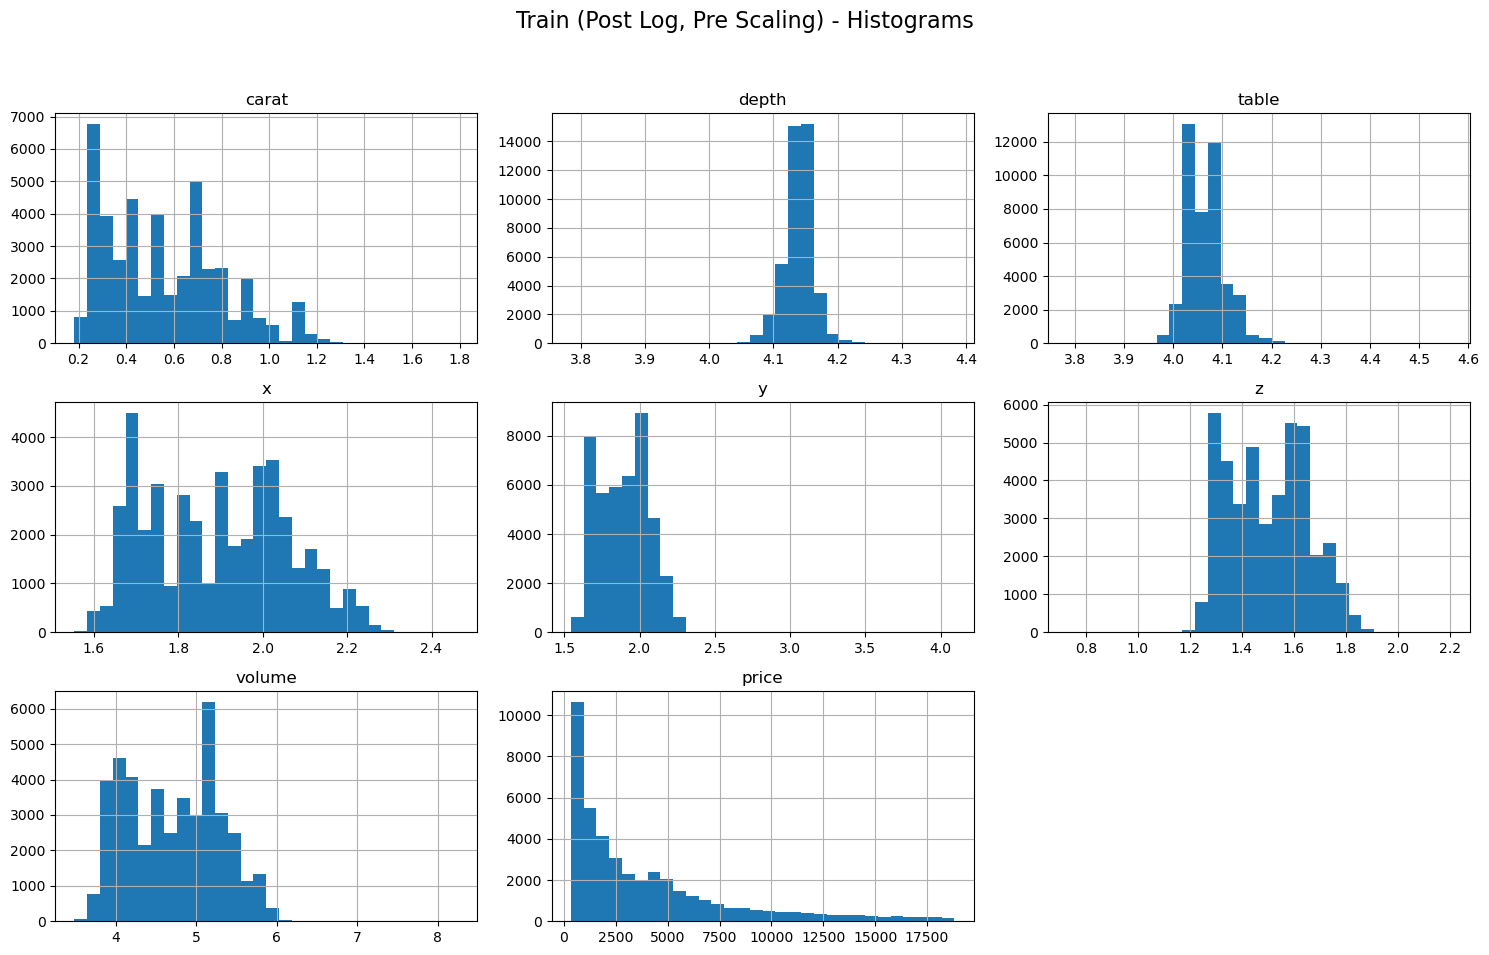


Generating Boxplots...


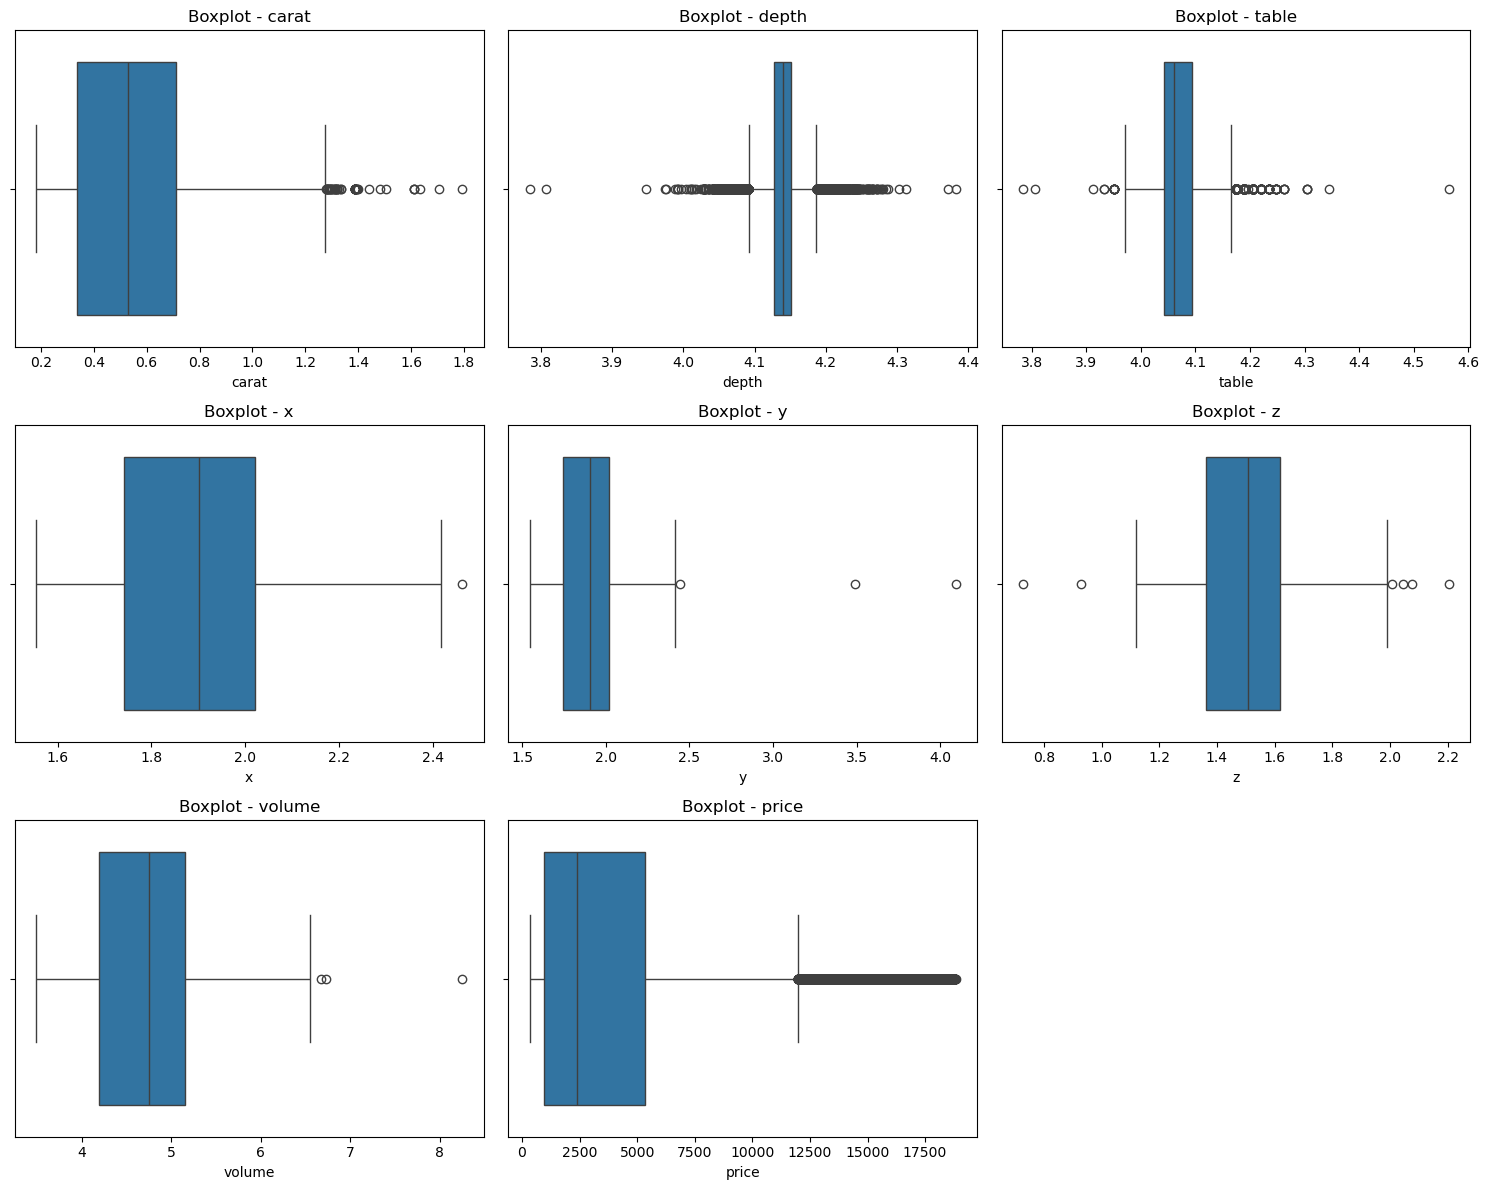


Generating Heatmap and Consolidated Boxplot...


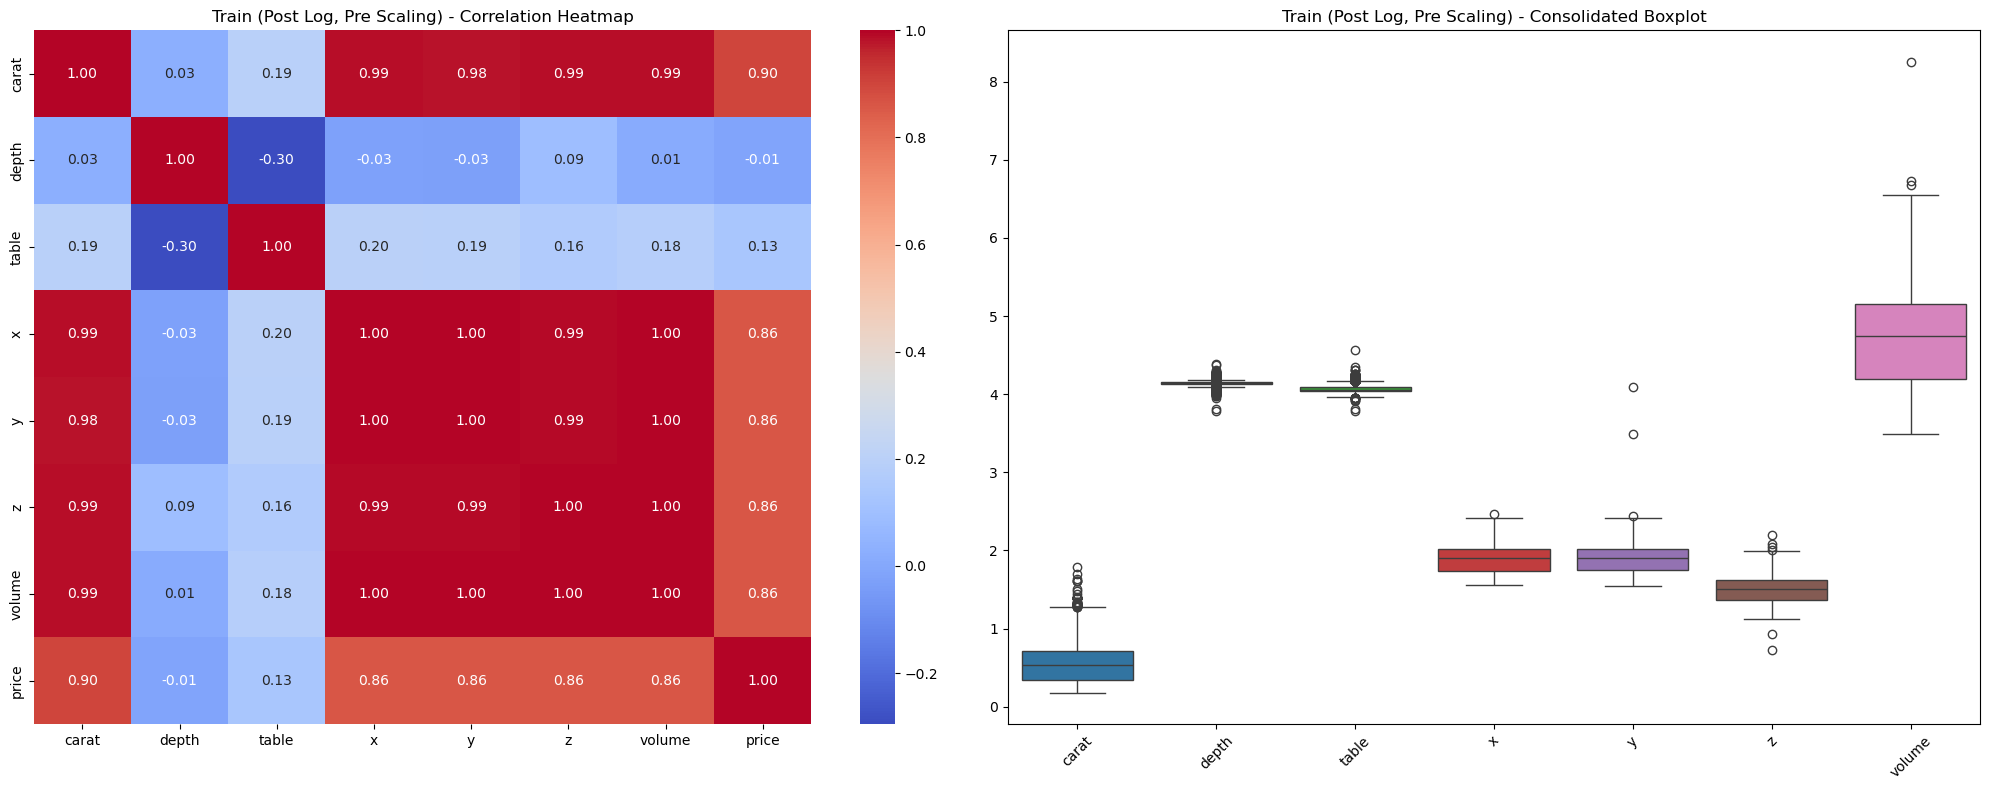


Diagnostics Completed Successfully!

Train (Post Log & Scaling)

Dataset Shape: 43035 rows × 8 columns

Total Duplicate Rows: 40

Total Missing Values: 41

Missing Values Per Column:
x: 6
y: 5
z: 15
volume: 15

Generating Histograms...


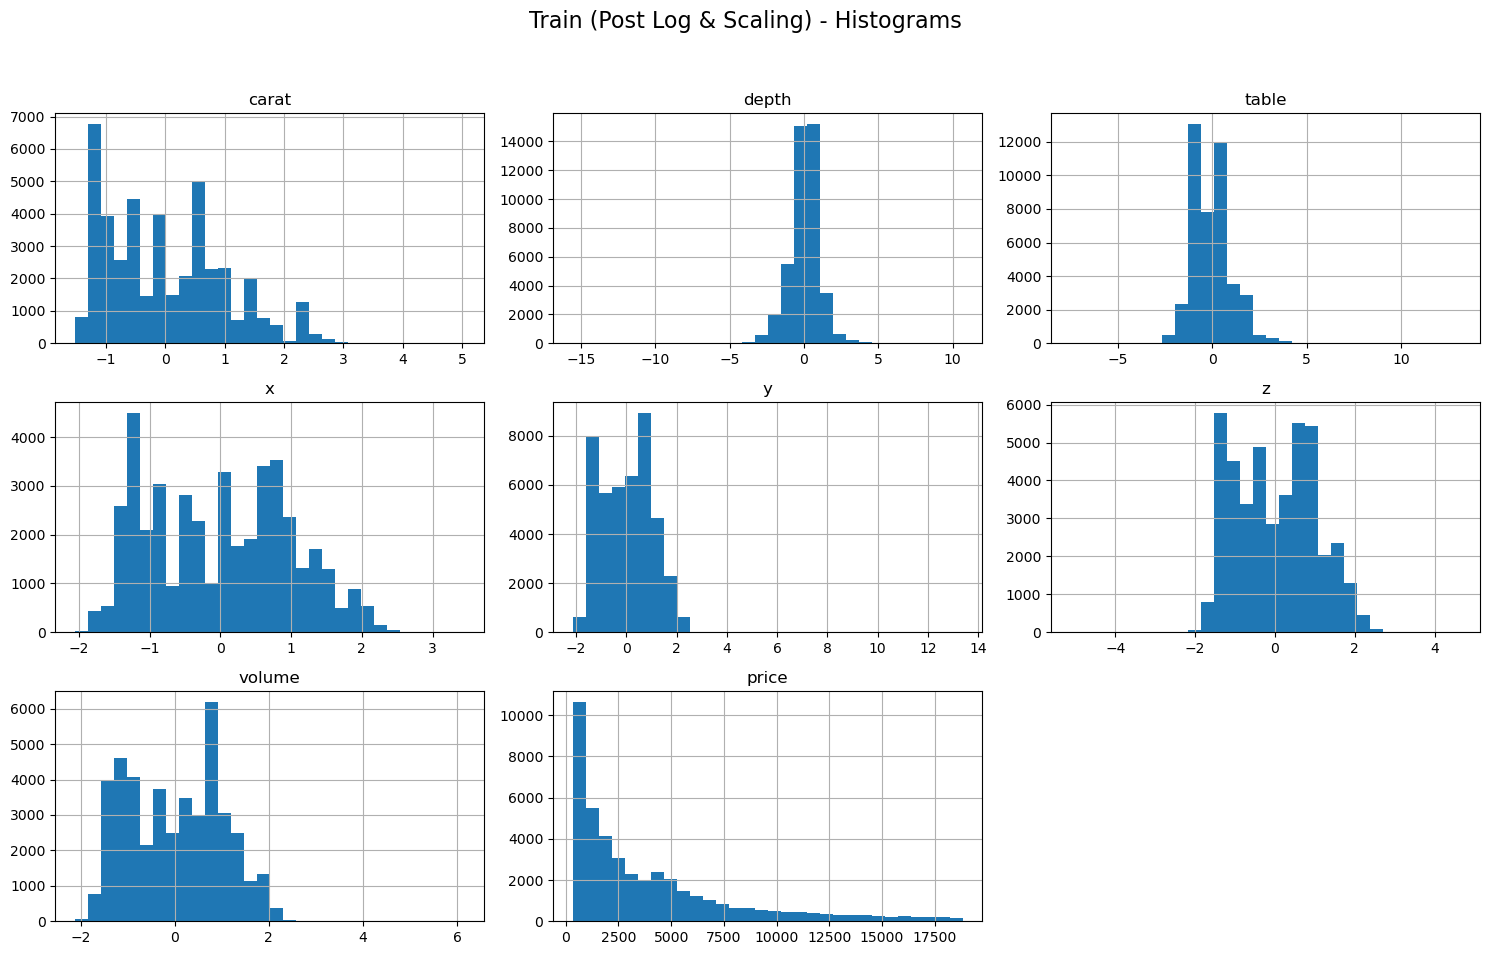


Generating Boxplots...


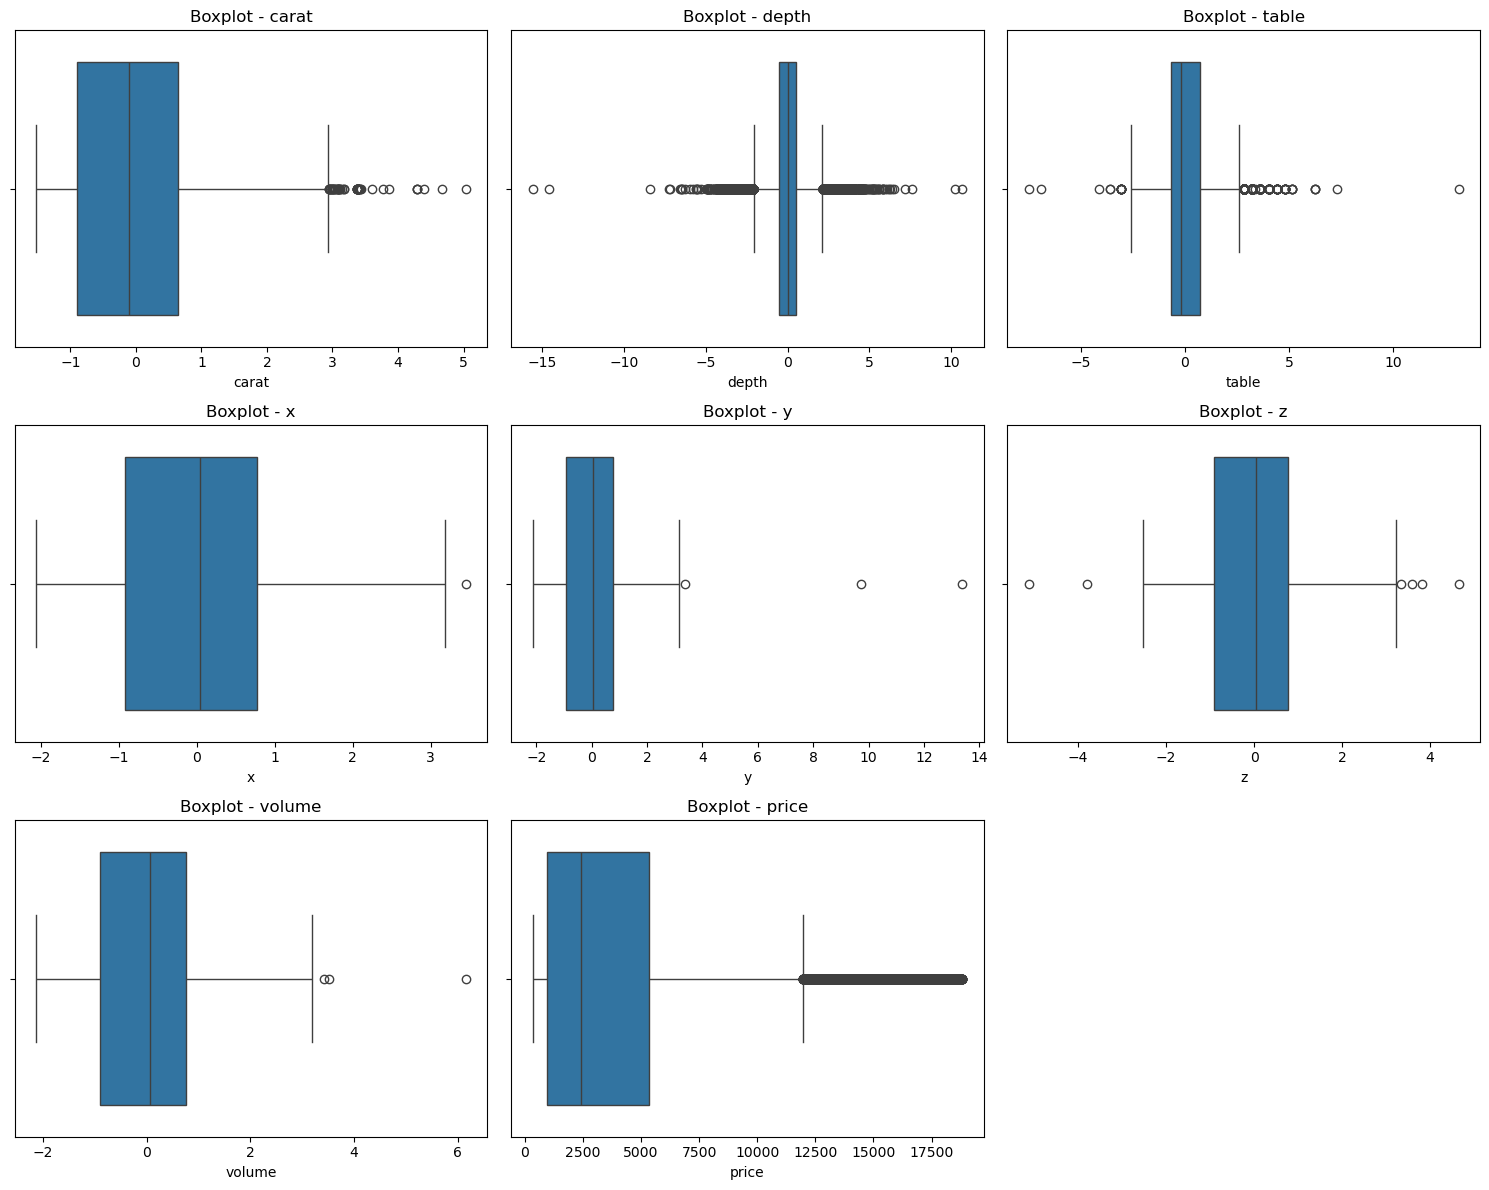


Generating Heatmap and Consolidated Boxplot...


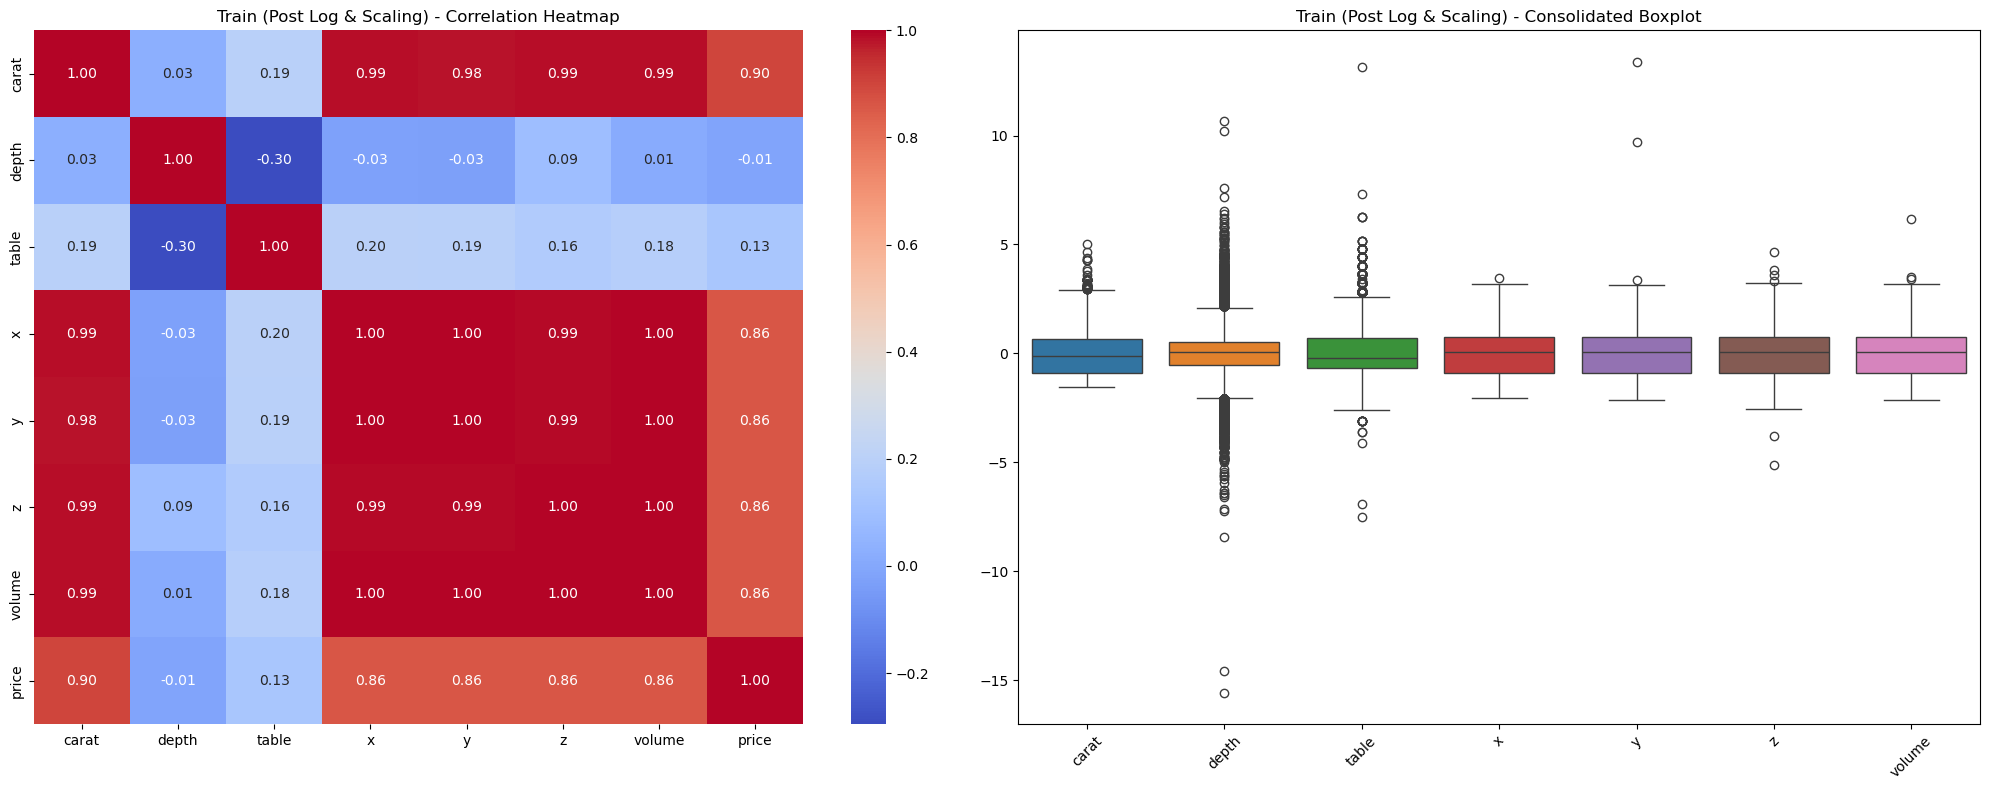


Diagnostics Completed Successfully!


In [23]:
# ==========================================
# LOAD DATA
# ==========================================

df = analyze_diamond_data()

# ==========================================
# MANUAL PREPROCESSING
# ==========================================

train_df, test_df = hf.preprocess_diamond_log(df)


Initial EDA - Untransformed Data

Dataset Shape: 53794 rows × 10 columns

Total Duplicate Rows: 0

Total Missing Values: 0

Missing Values Per Column:
No Missing Values

Generating Histograms...


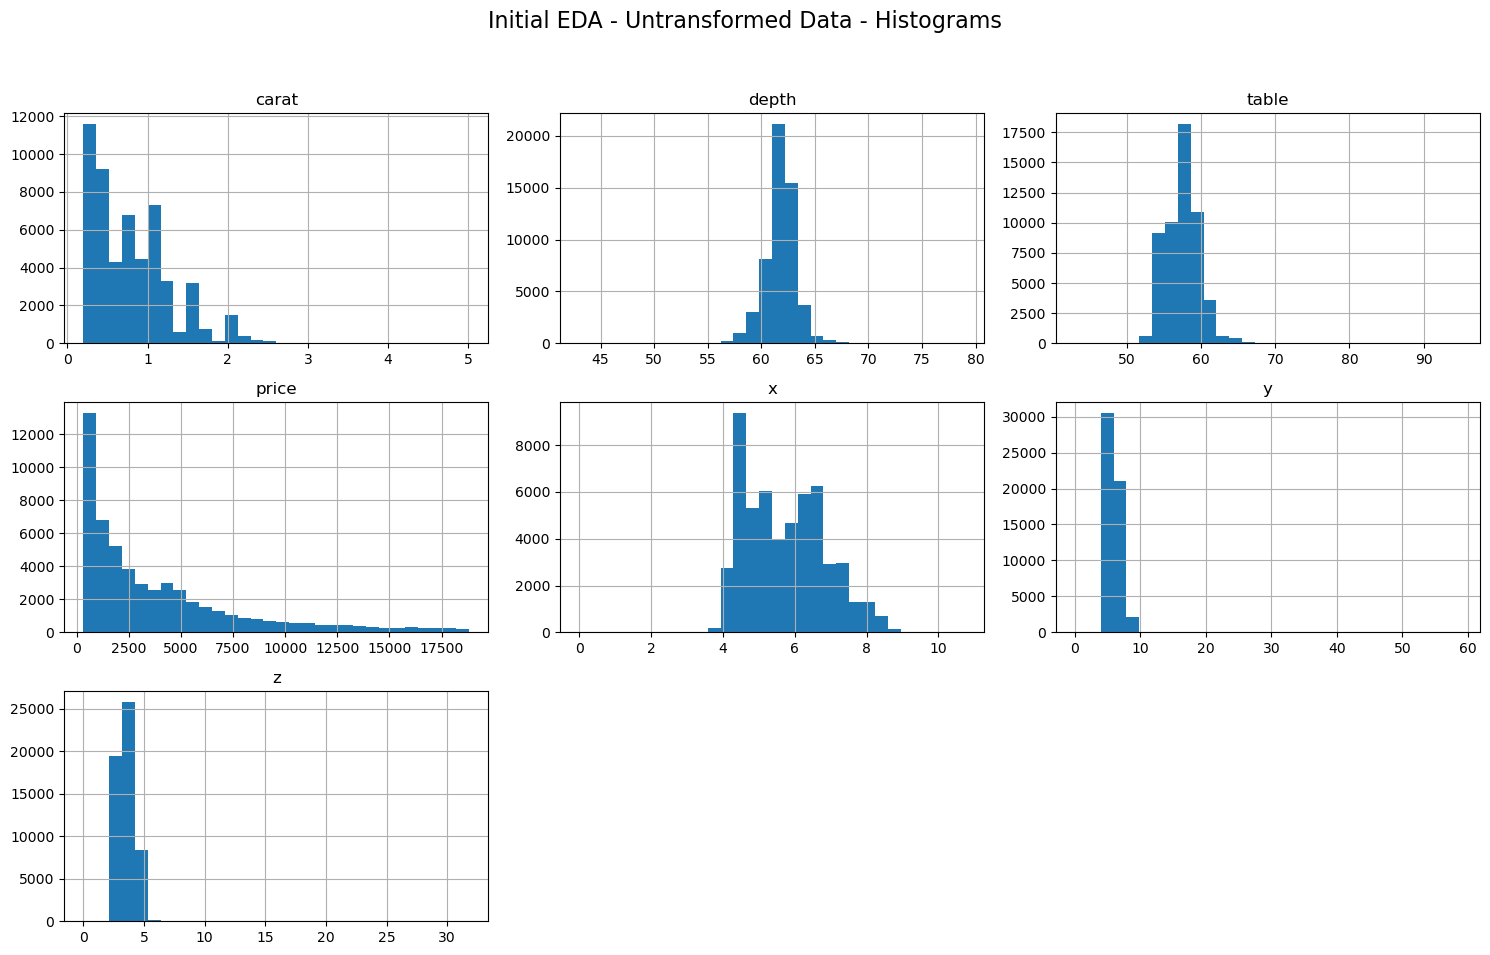


Generating Boxplots...


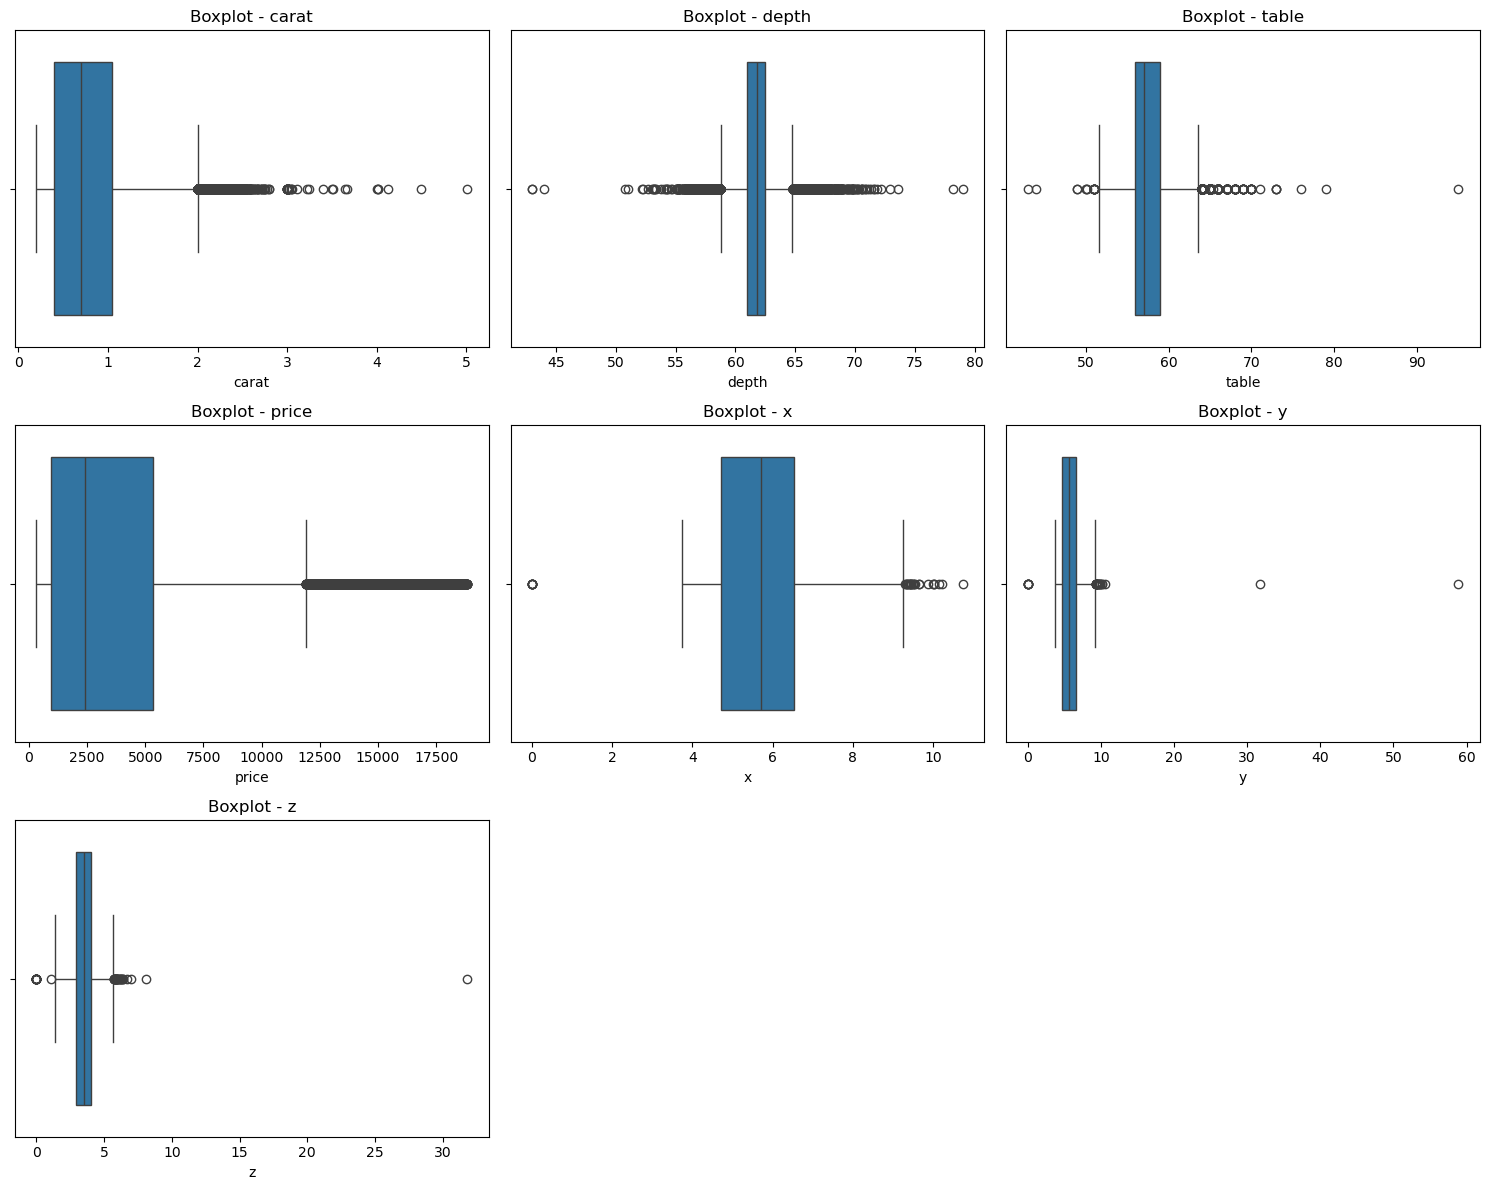


Generating Heatmap and Consolidated Boxplot...


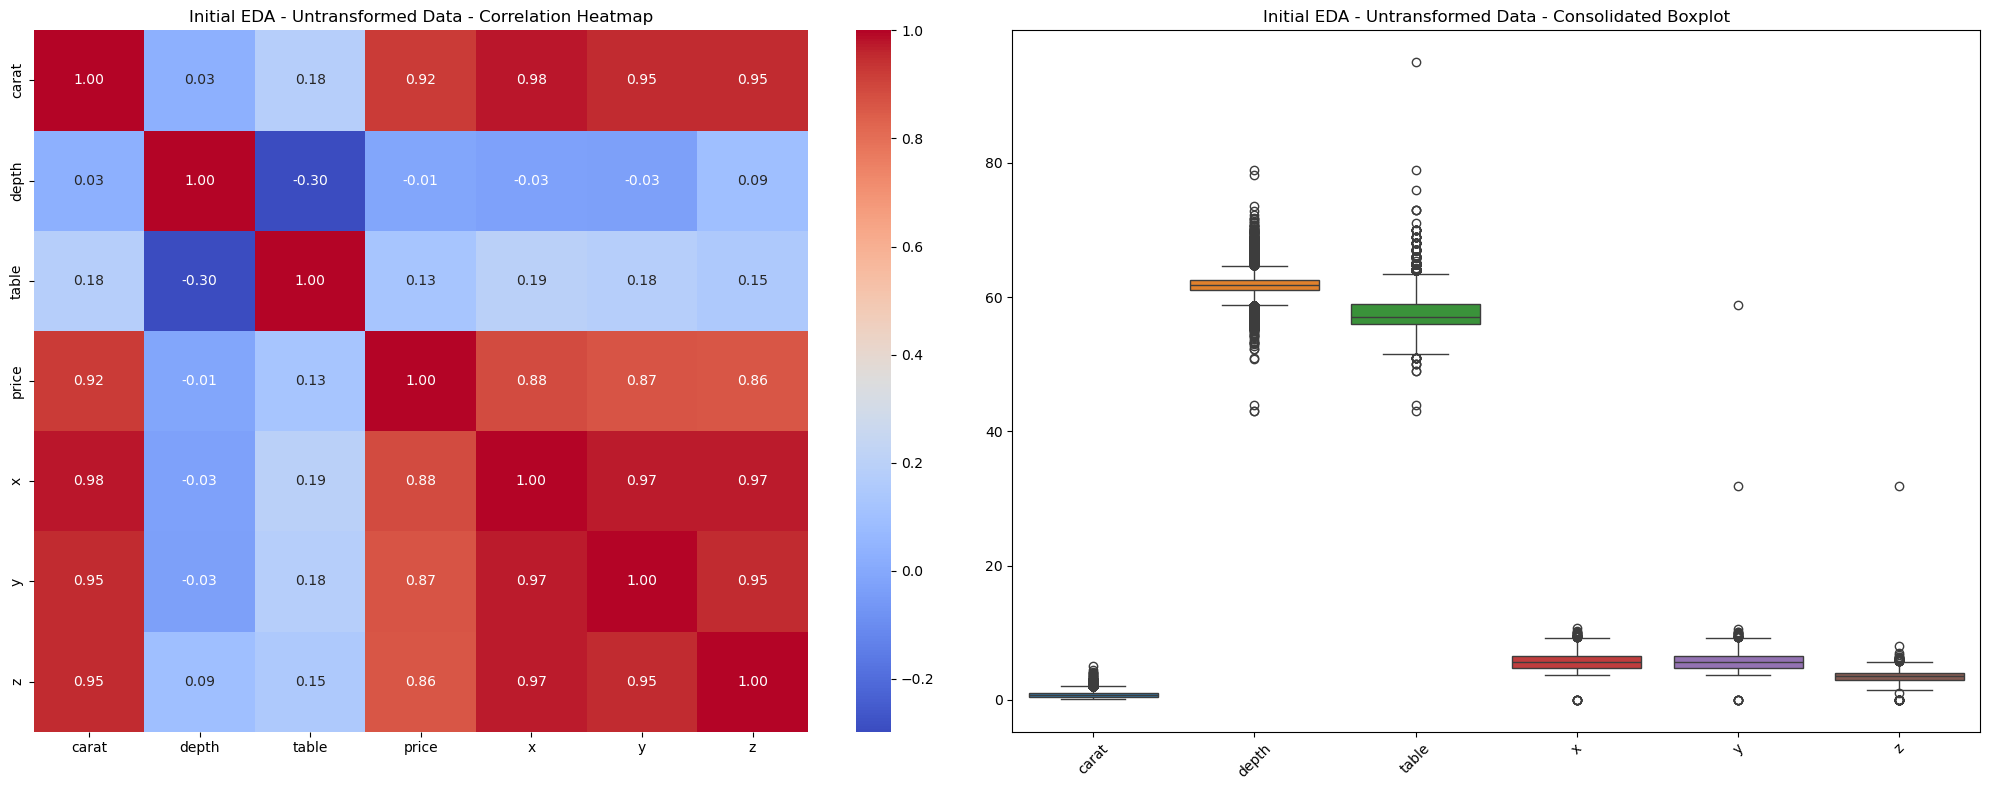


Generating Count Plots...


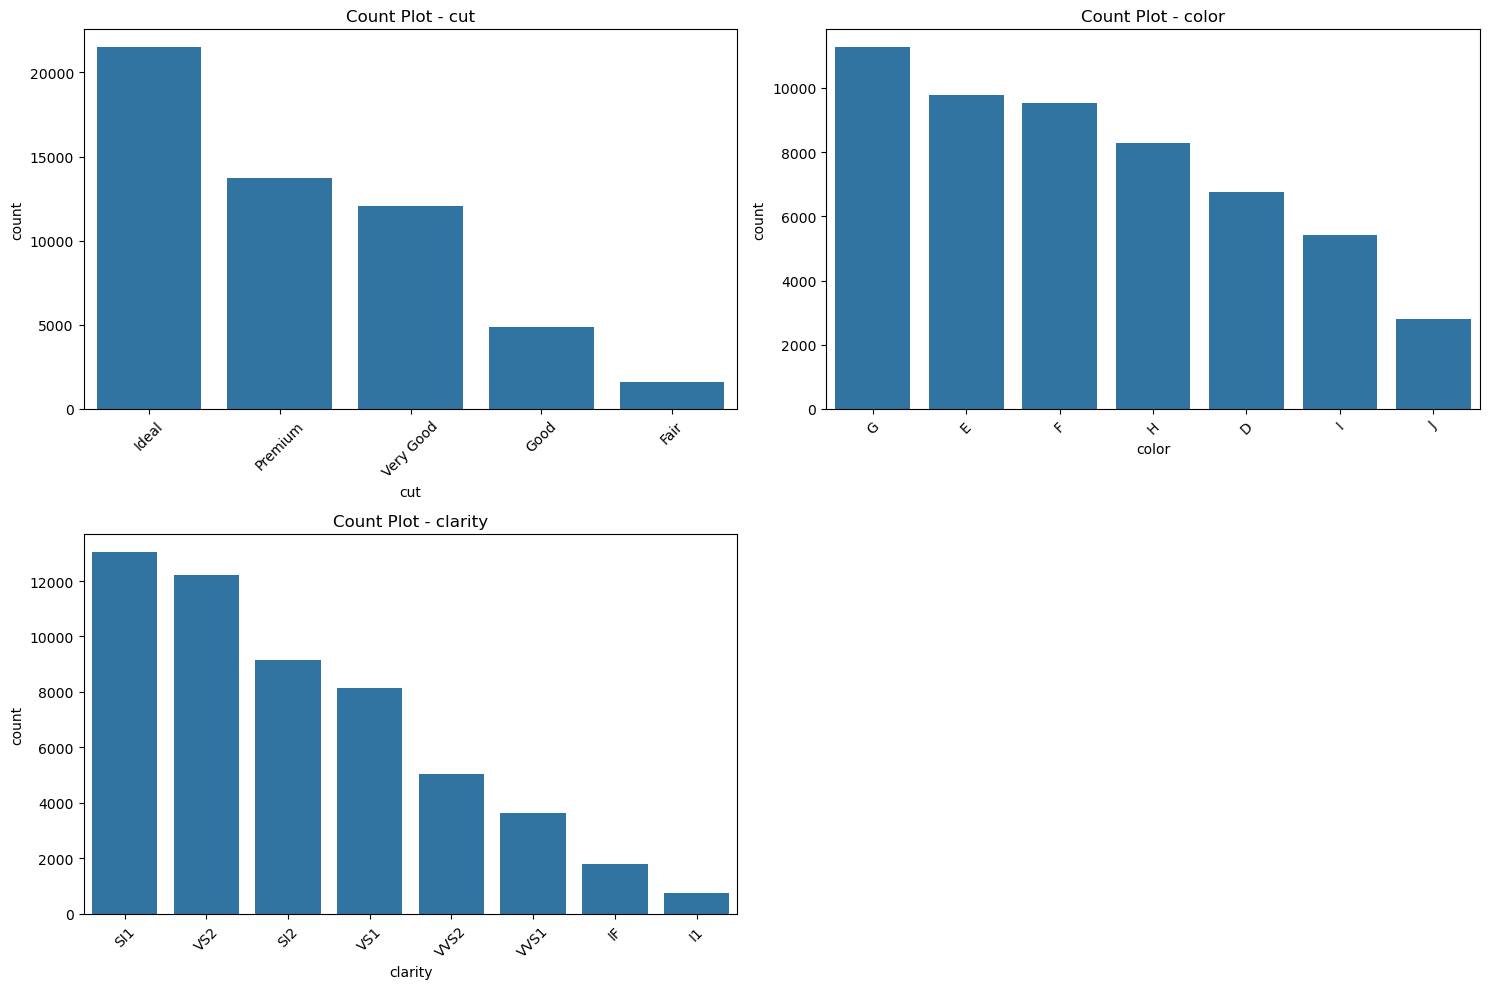


Diagnostics Completed Successfully!

Train-Test Split Completed

X_train Shape : (43035, 7)
X_test Shape  : (10759, 7)

y_train Shape : (43035,)
y_test Shape  : (10759,)

Train (Post Log, Pre Scaling)

Dataset Shape: 43035 rows × 8 columns

Total Duplicate Rows: 40

Total Missing Values: 41

Missing Values Per Column:
x: 6
y: 5
z: 15
volume: 15

Generating Histograms...


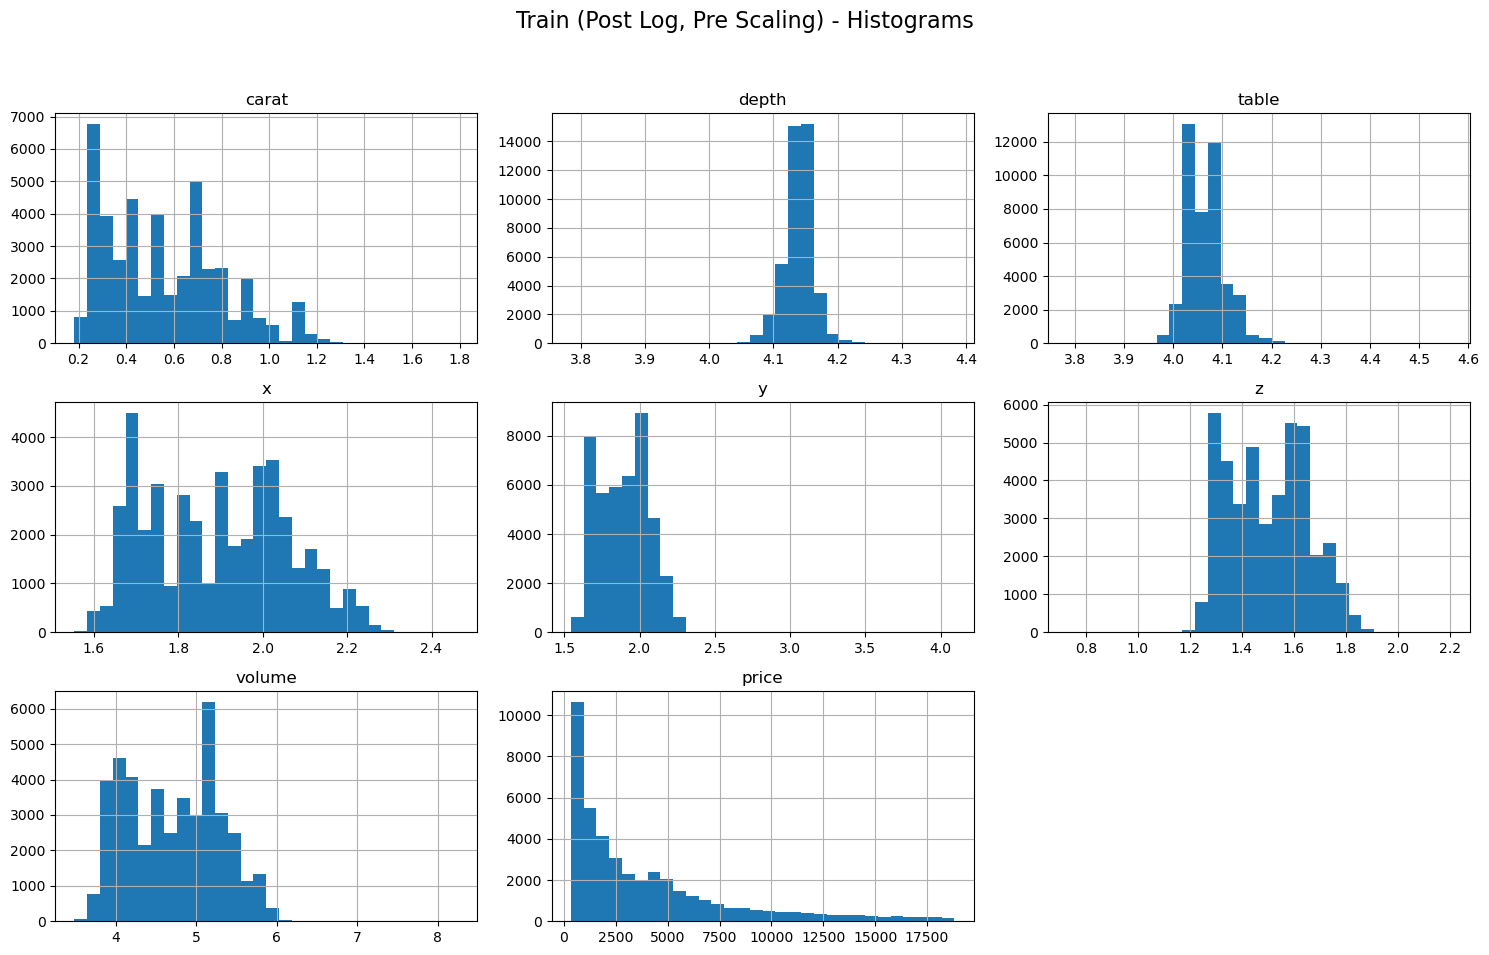


Generating Boxplots...


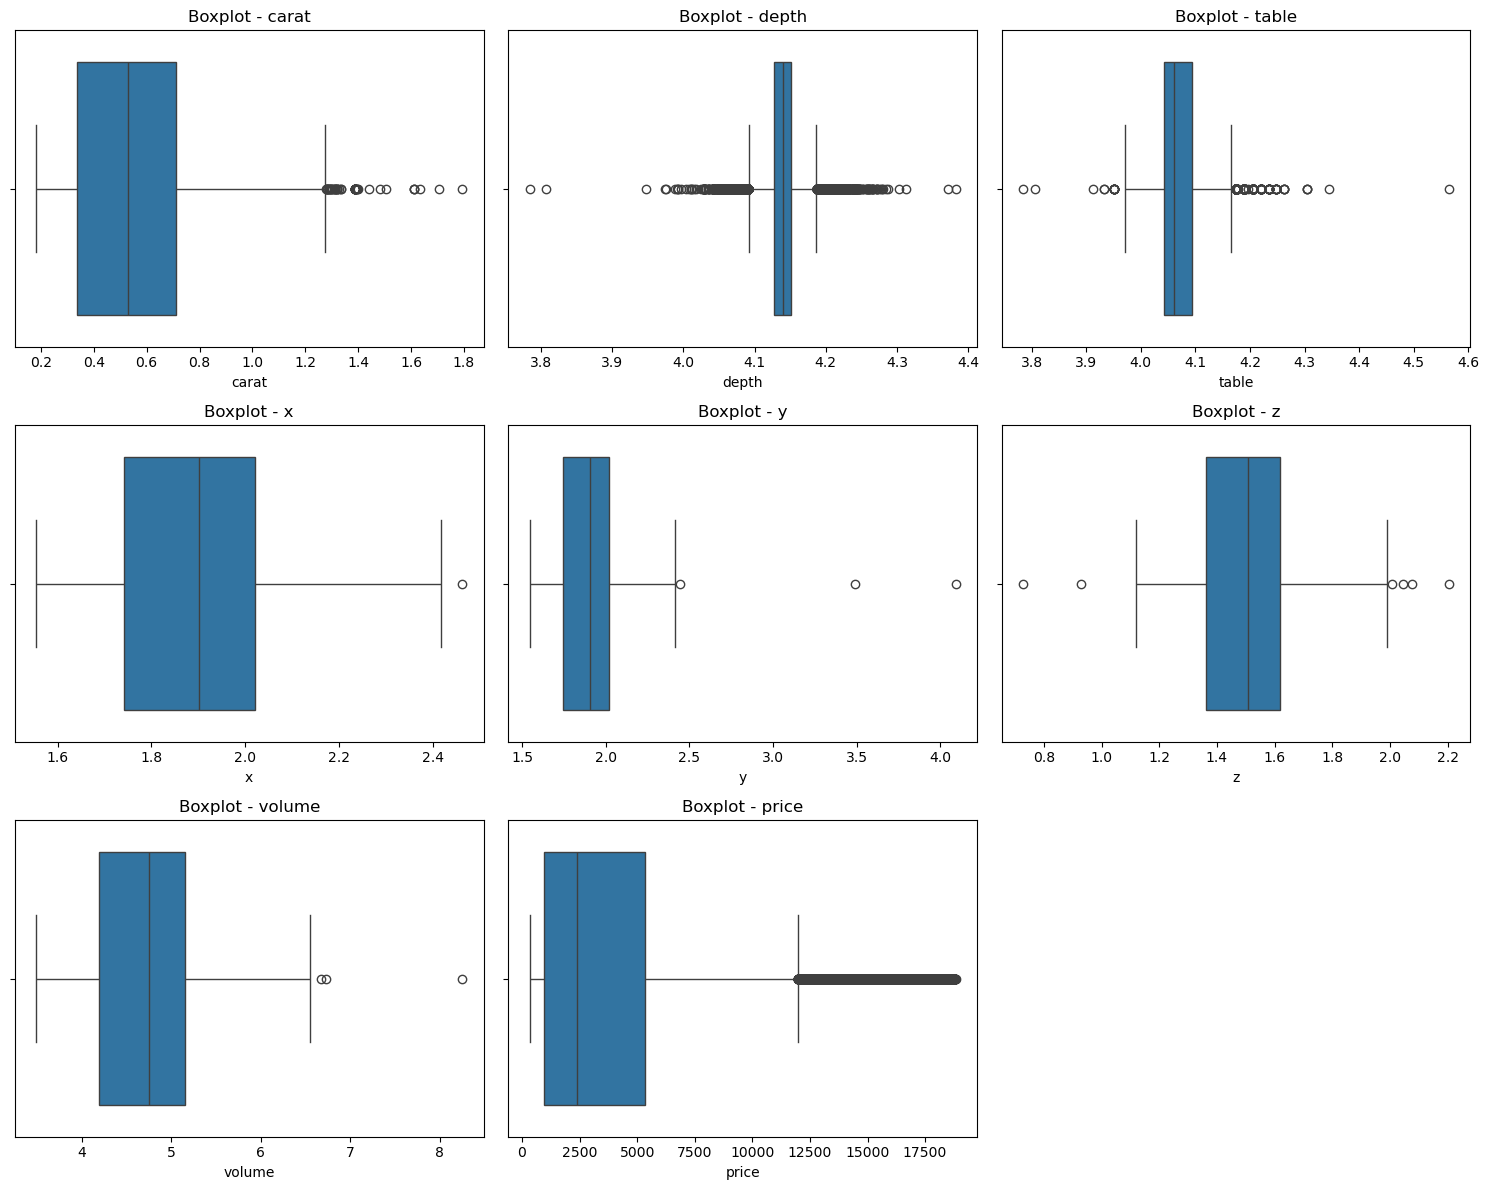


Generating Heatmap and Consolidated Boxplot...


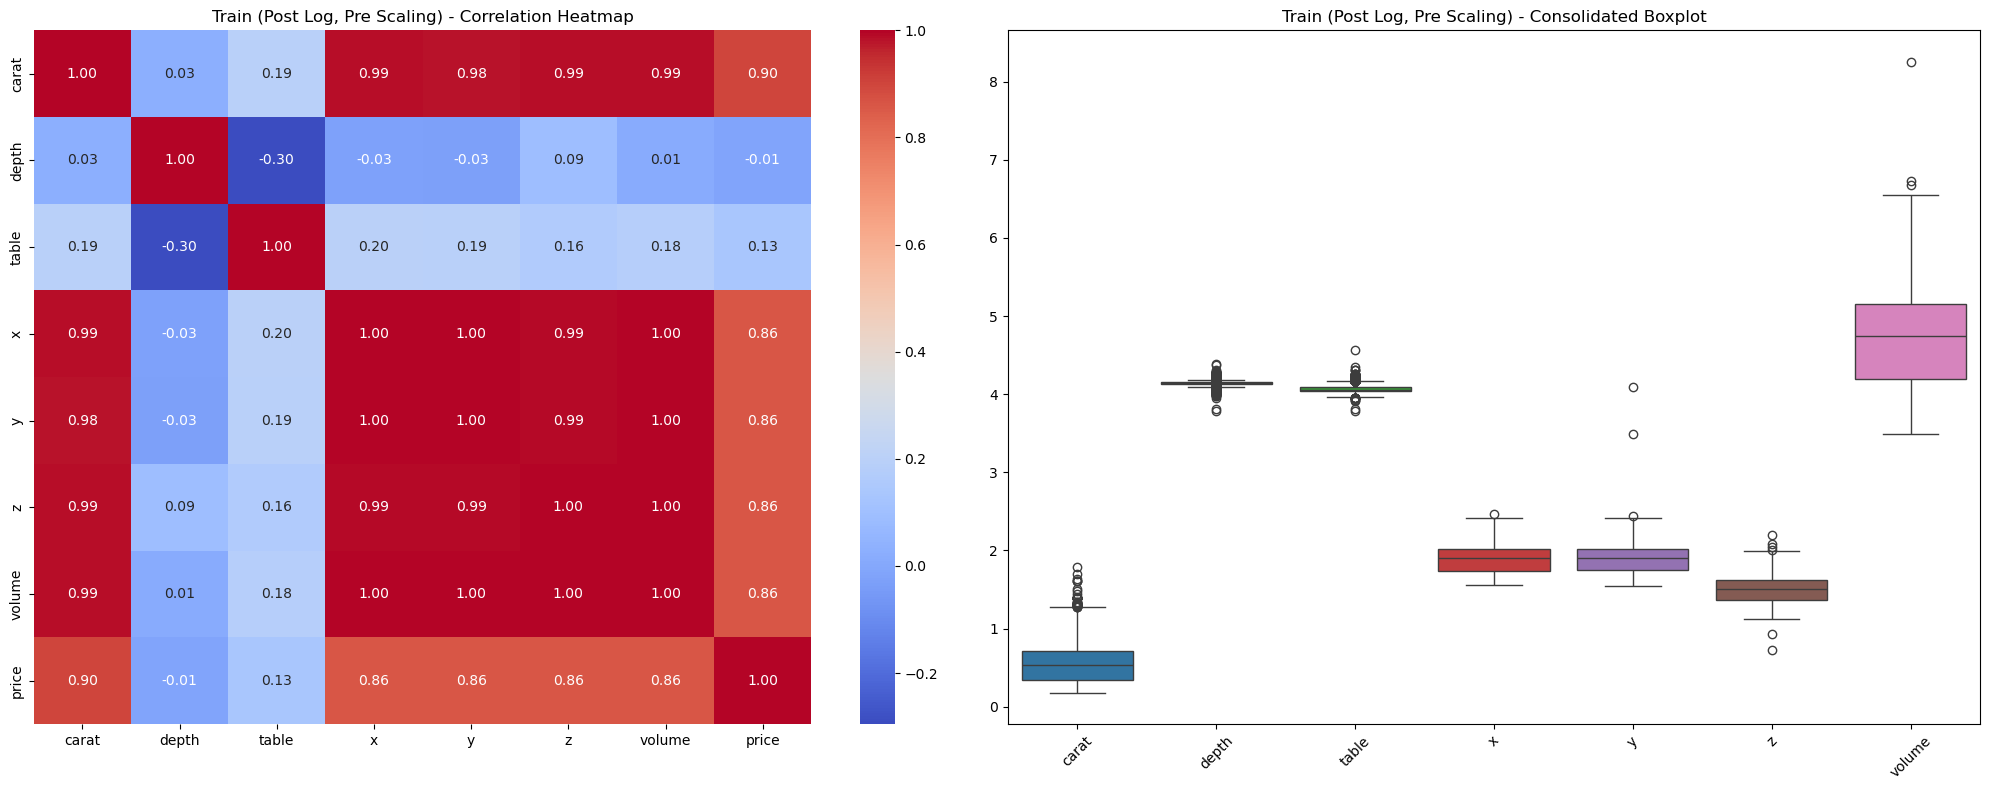


Diagnostics Completed Successfully!

Train (Post Log & Scaling)

Dataset Shape: 43035 rows × 8 columns

Total Duplicate Rows: 40

Total Missing Values: 41

Missing Values Per Column:
x: 6
y: 5
z: 15
volume: 15

Generating Histograms...


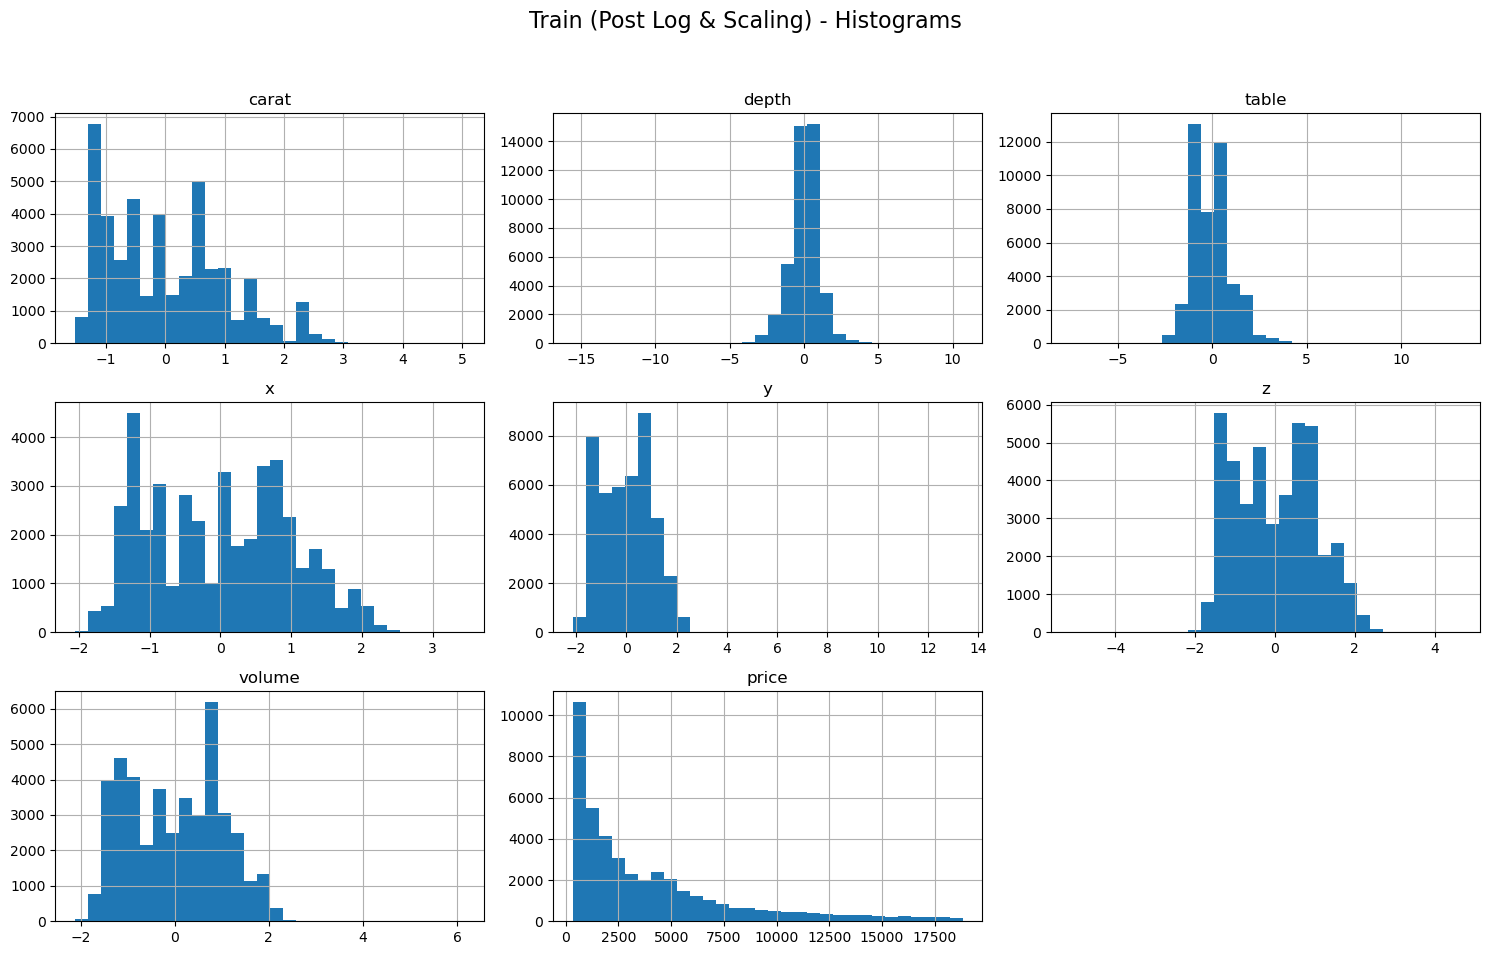


Generating Boxplots...


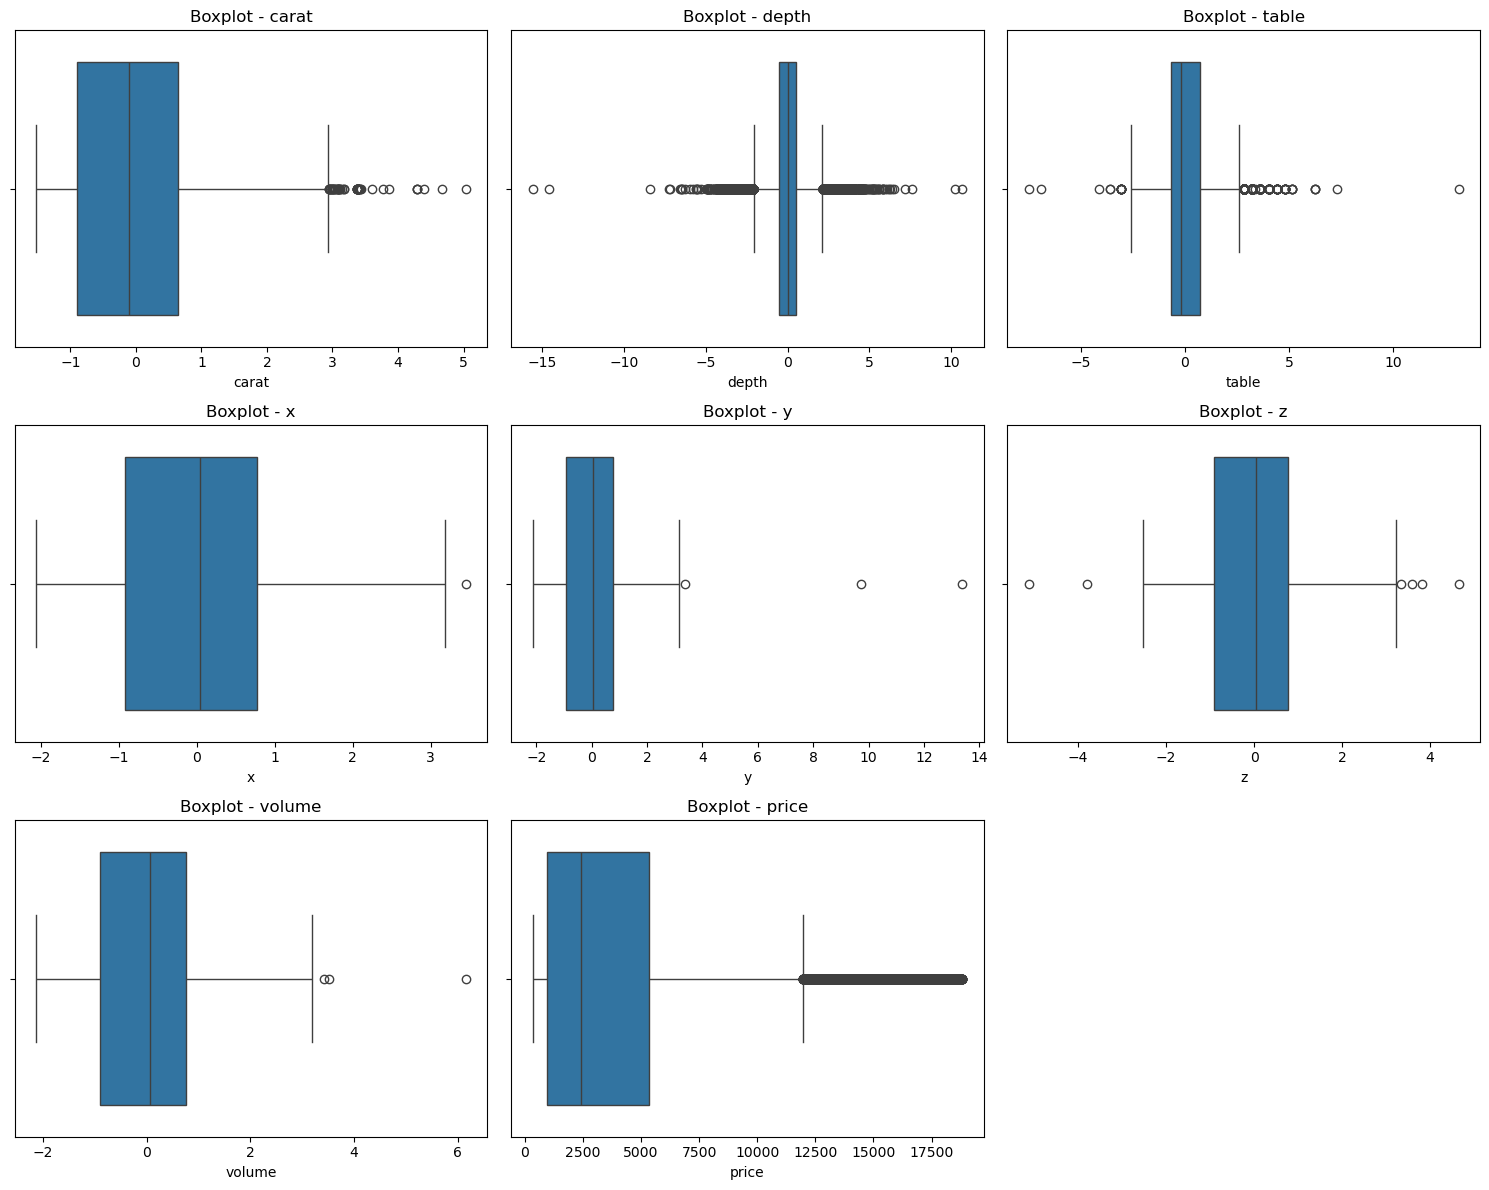


Generating Heatmap and Consolidated Boxplot...


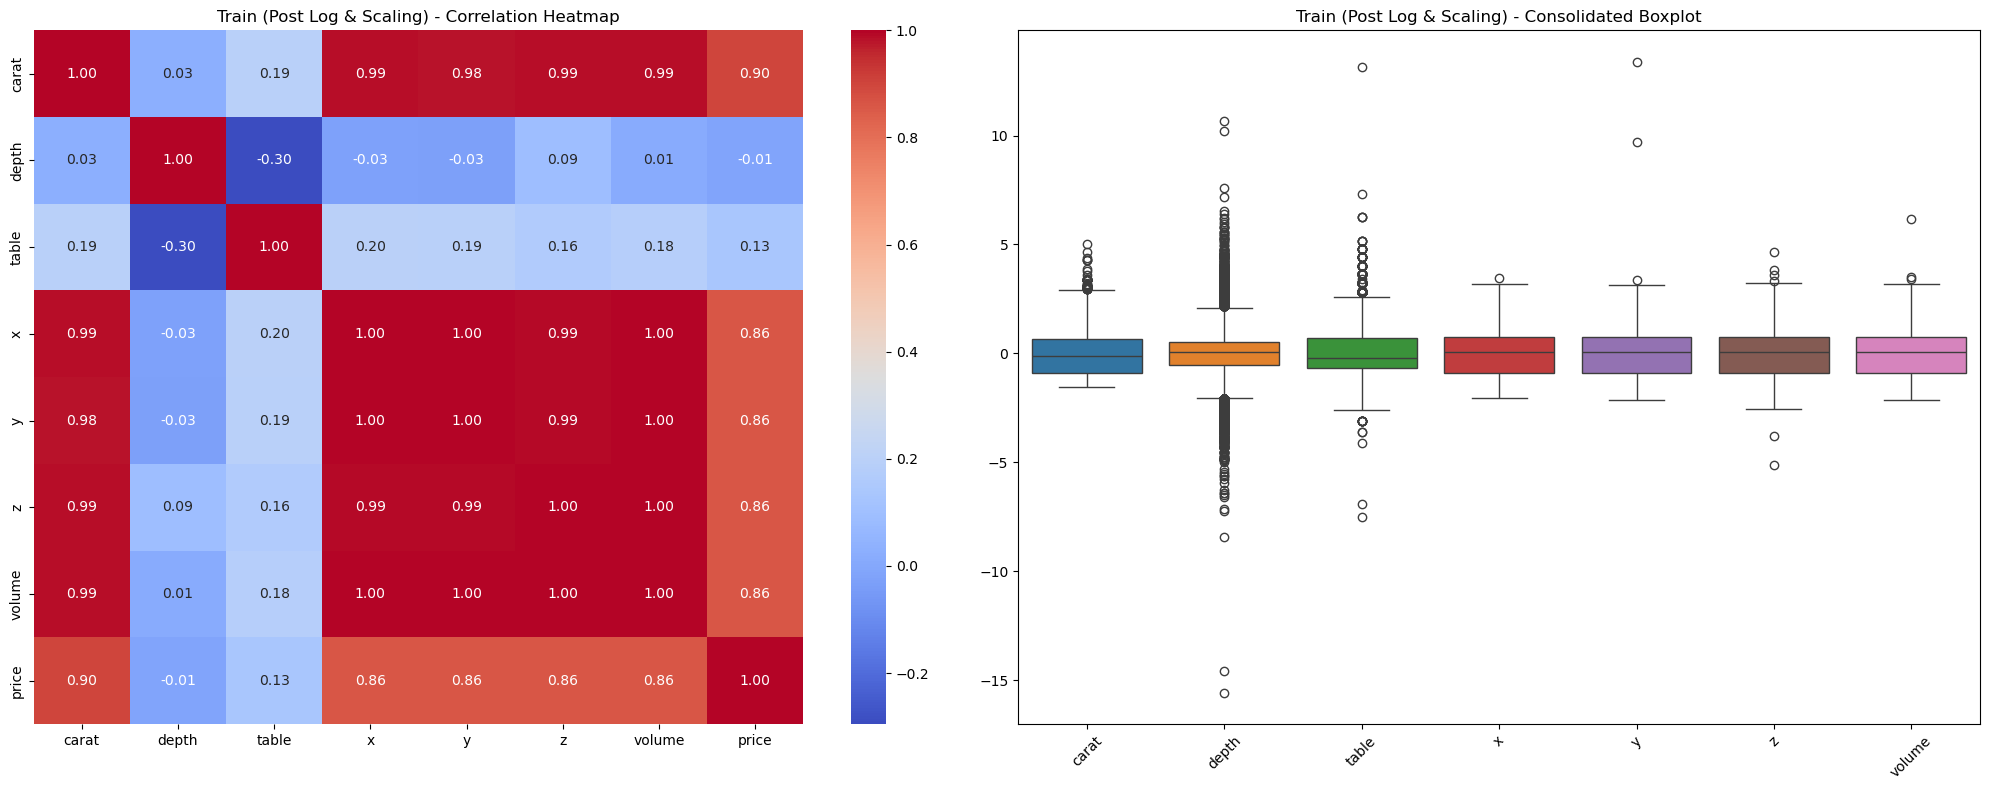


Diagnostics Completed Successfully!


In [28]:
# ==========================================
# LOAD DATA
# ==========================================

df = analyze_diamond_data()

# ==========================================
# MANUAL PREPROCESSING
# ==========================================

train_df, test_df = hf.preprocess_diamond_log(df)


Initial EDA - Untransformed Data

Dataset Shape: 53794 rows × 10 columns

Total Duplicate Rows: 0

Total Missing Values: 0

Missing Values Per Column:
No Missing Values

Generating Histograms...


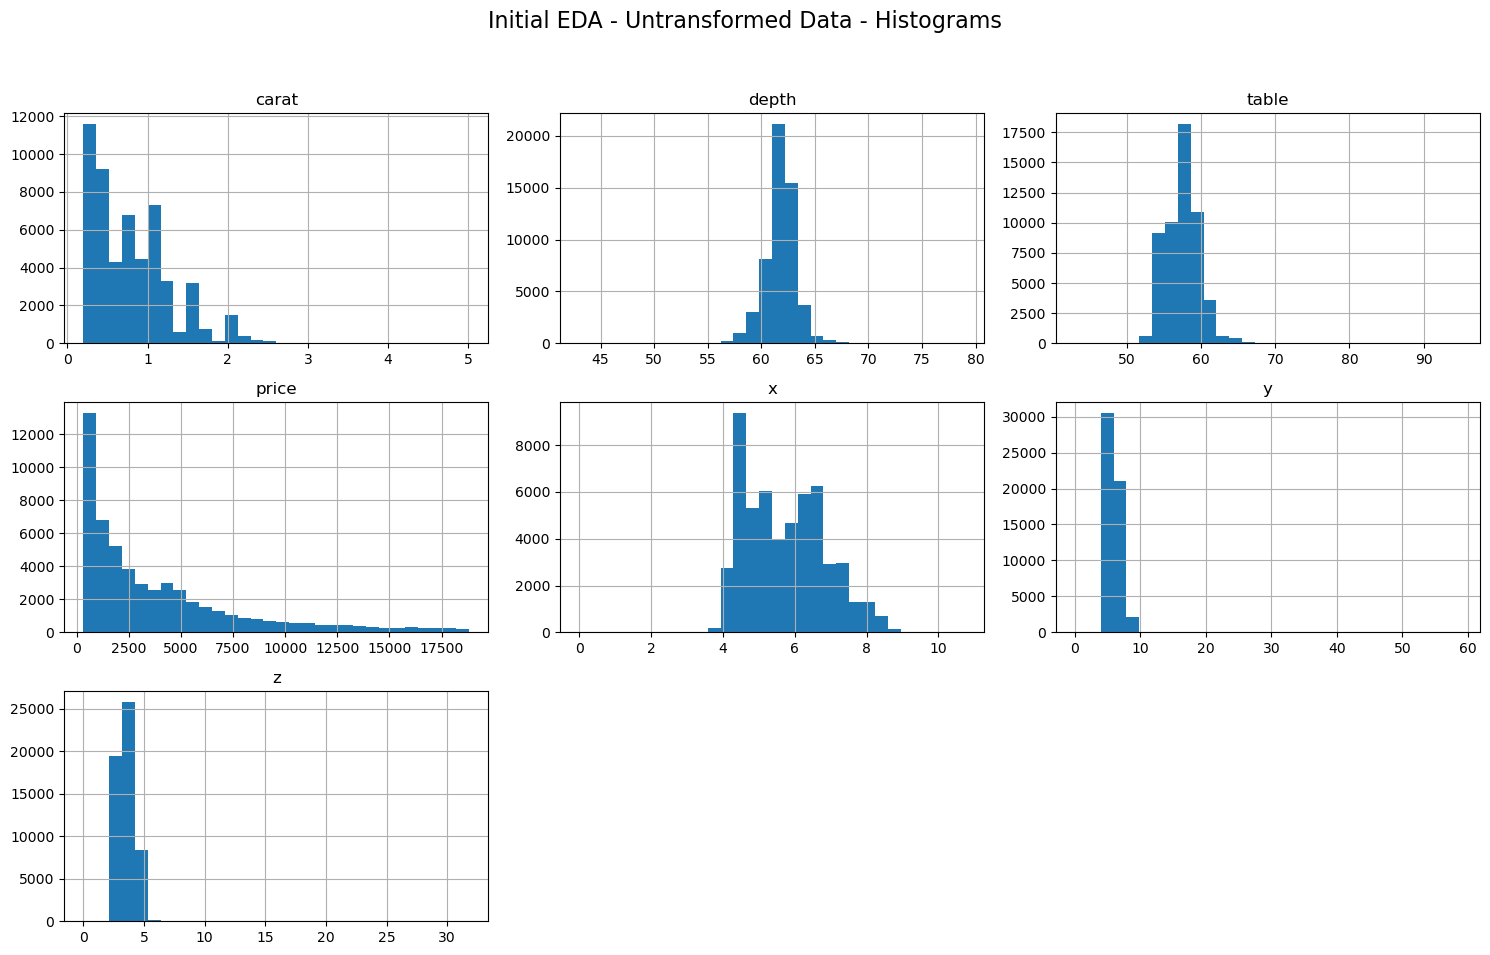


Generating Boxplots...


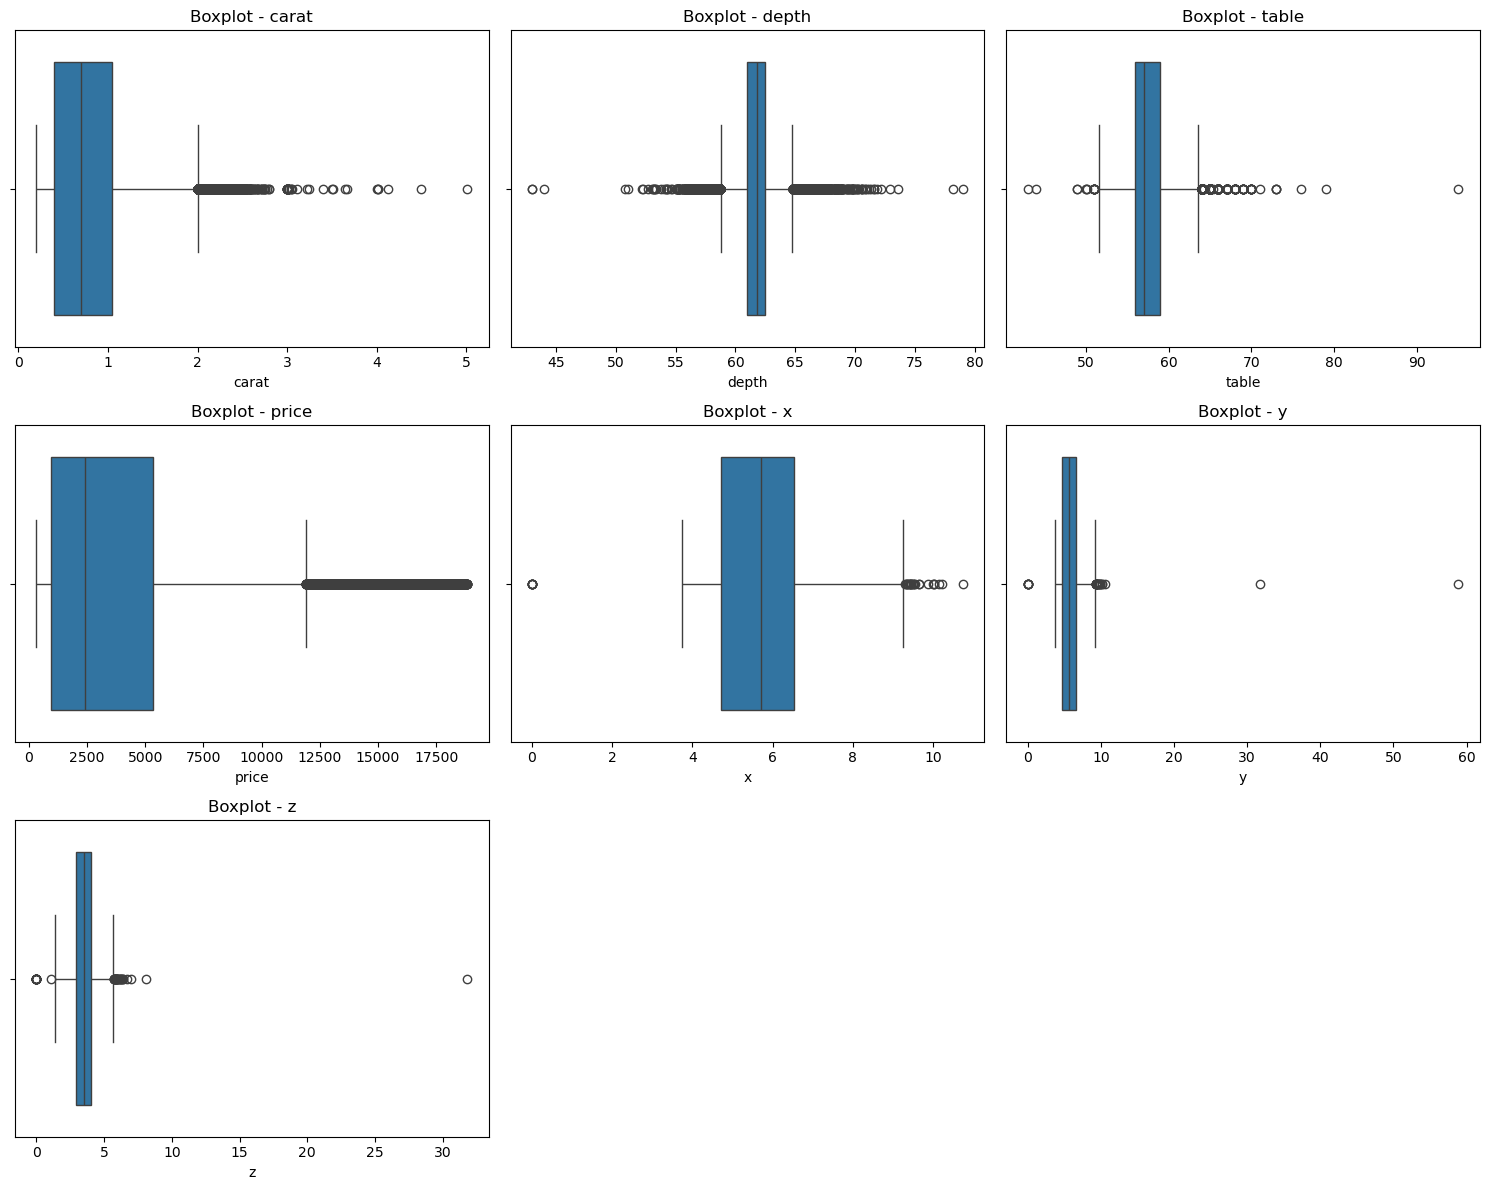


Generating Heatmap and Consolidated Boxplot...


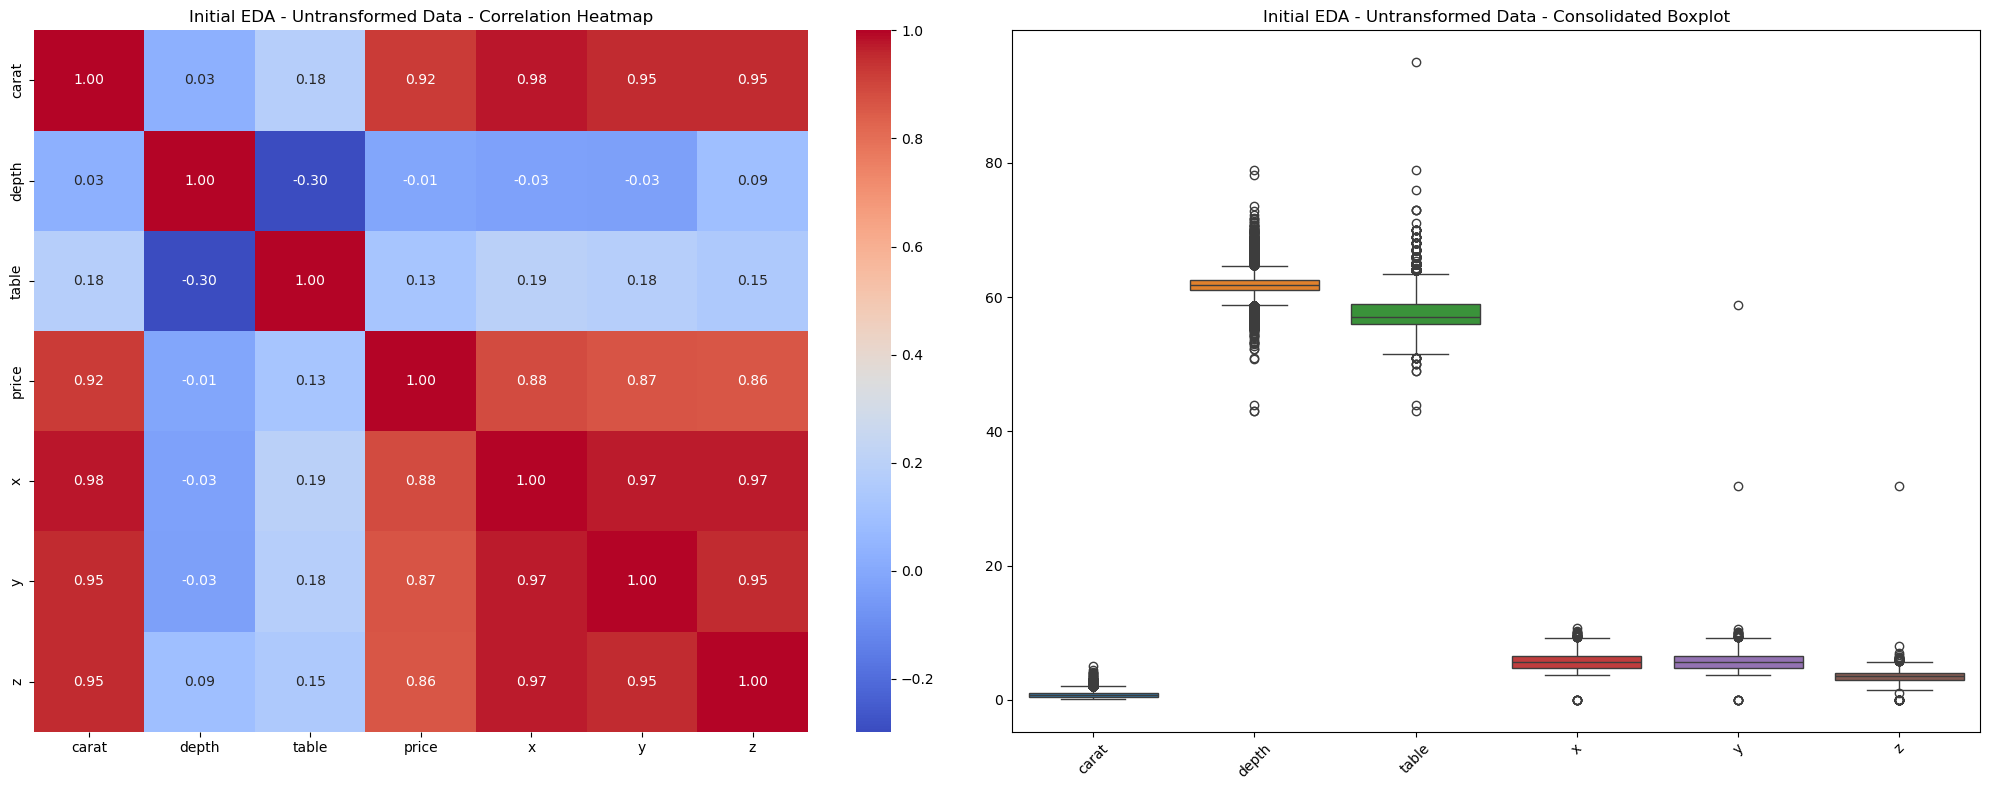


Generating Count Plots...


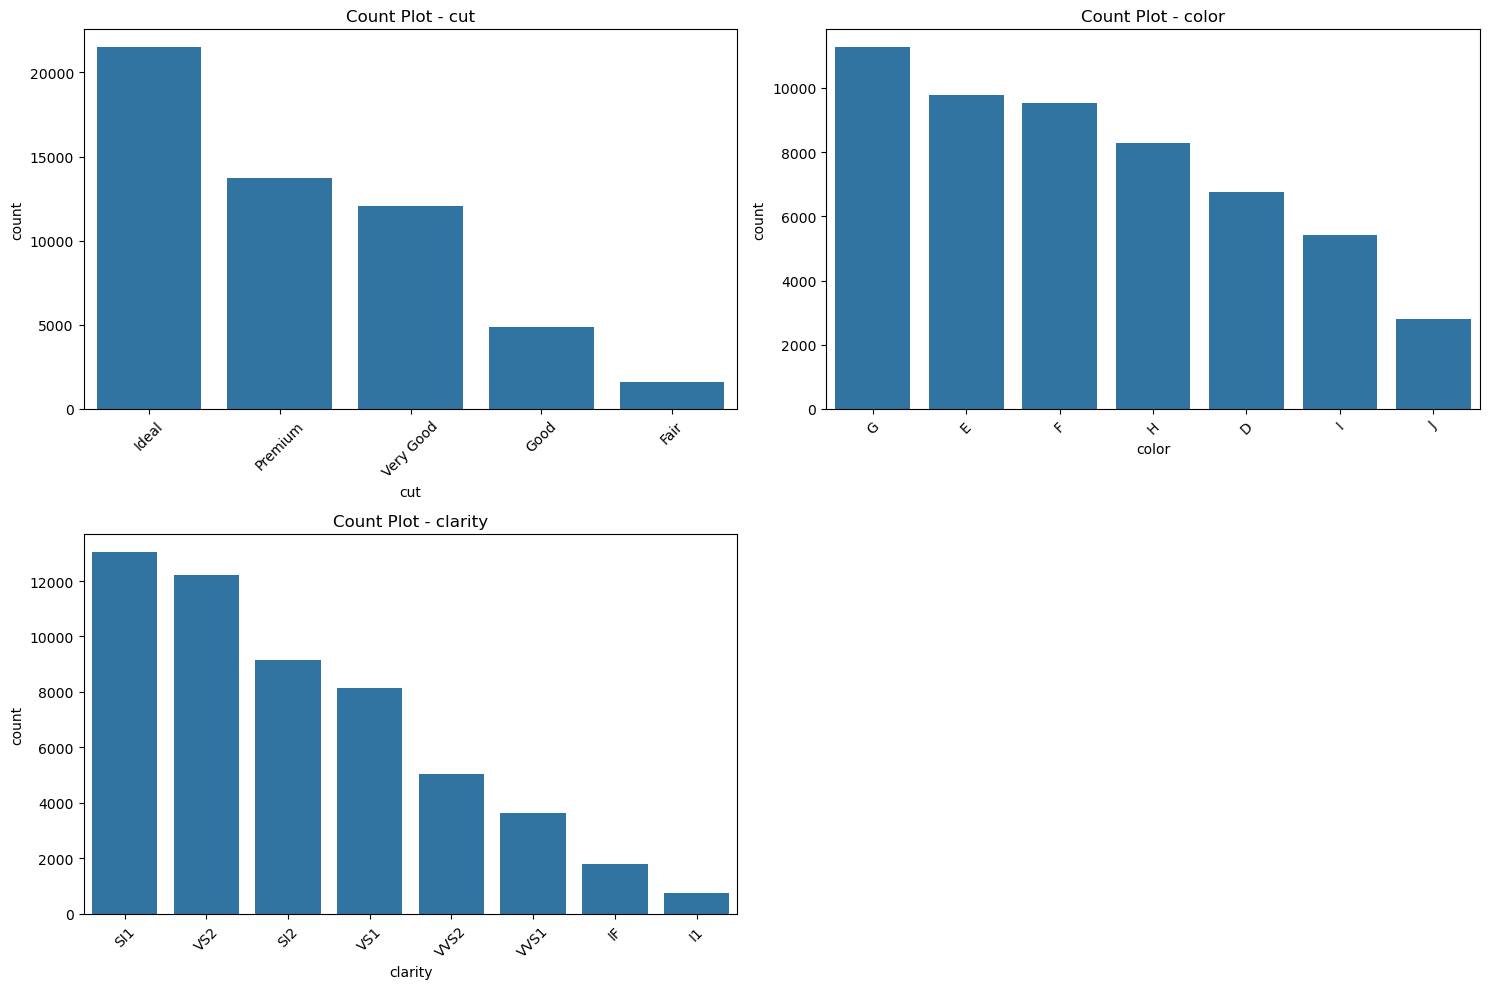


Diagnostics Completed Successfully!

Training Data Metrics
RMSE : 526.3220
MAE  : 296.4762
R²   : 0.9828


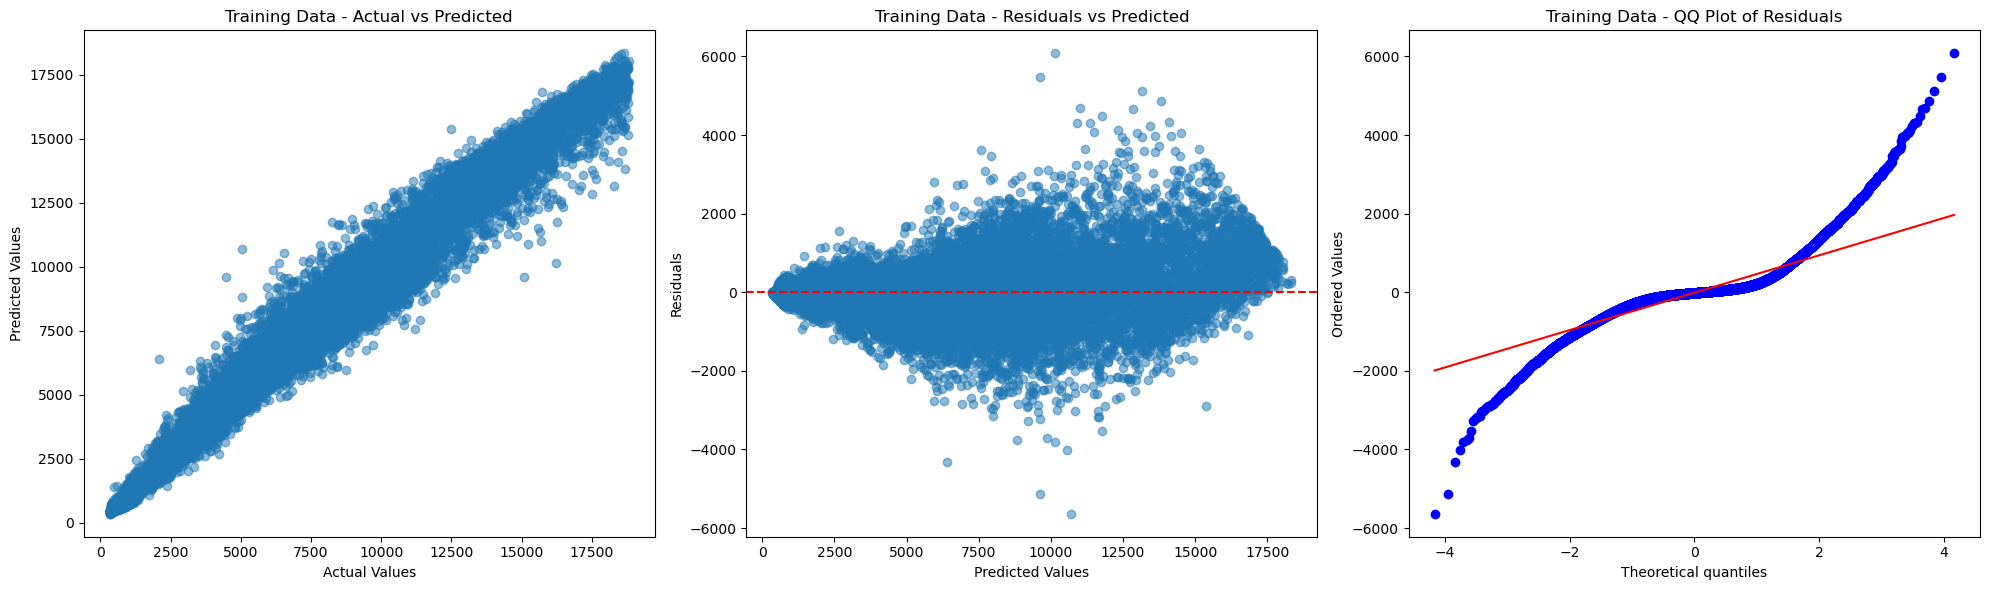


Test Data Metrics
RMSE : 1341.2260
MAE  : 766.3338
R²   : 0.8820


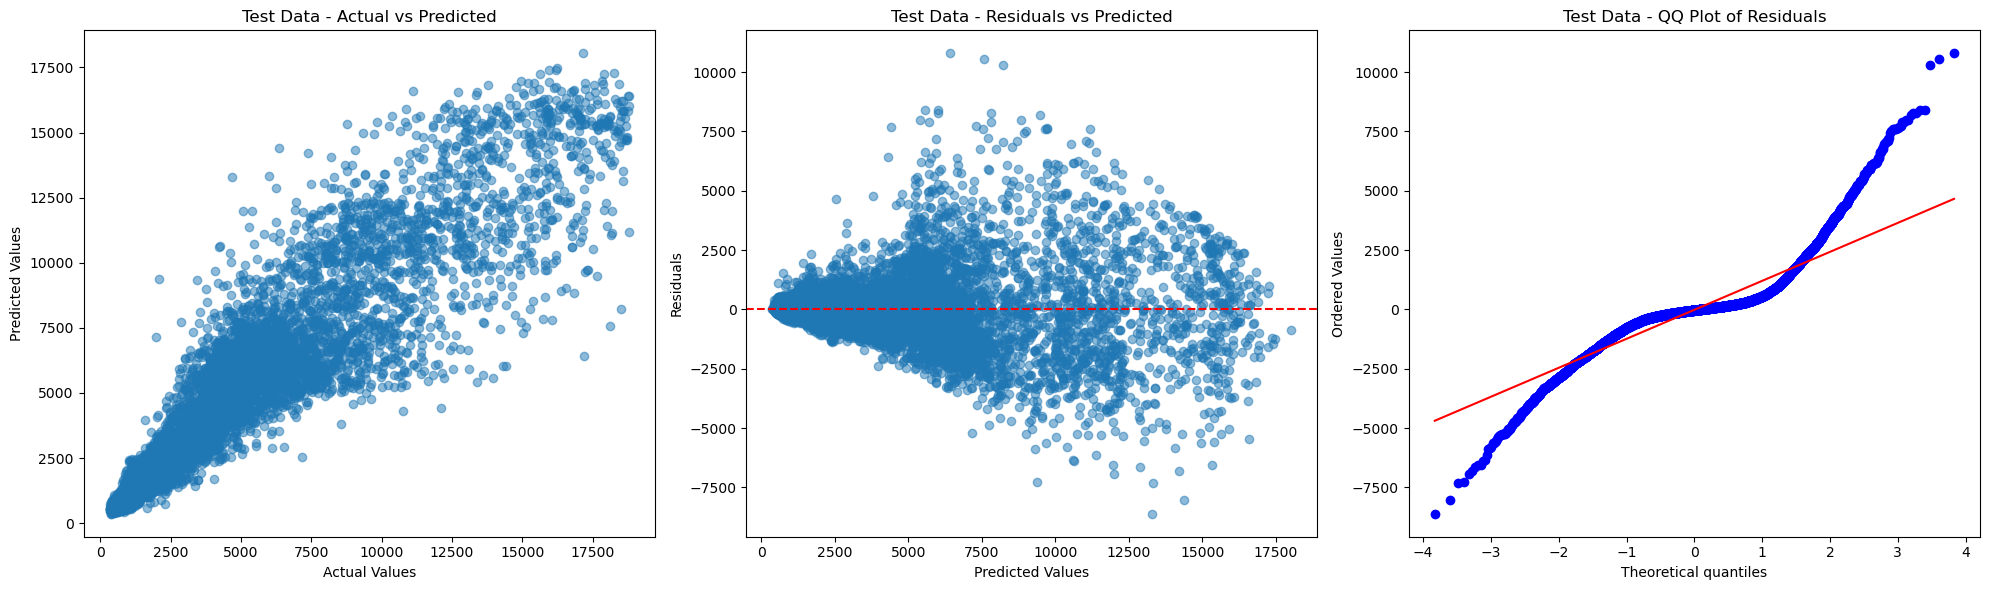

In [29]:
# ==========================================
# RELOAD RAW DATA
# ==========================================

df_pipeline = analyze_diamond_data()

# ==========================================
# RUN FINAL PIPELINE
# ==========================================

final_pipeline = hf.run_pipeline_log(
    df_pipeline, target_col='price'
)